In [1]:
import os

# change directory one up 
os.chdir('..')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def load_and_concat_shift_files(folder_path, prefix, column_name, pos=-1):
    """
    Load CSV files from folder_path that start with prefix, sort them based on the number
    at the end of the filename, add a column with that number, and concatenate all into a single DataFrame.
    
    Args:
        folder_path (str): Path to the folder containing the CSV files.
        prefix (str): Prefix of the files to include.
        column_name (str): Name of the new column to store the shift number.
        idx (int): Index of the parameter to shift (default: -1 for last parameter).

    Returns:
        pd.DataFrame: Concatenated DataFrame of all relevant CSVs with shift column added.
    """
    files = os.listdir(folder_path)
    shift_files = [f for f in files if f.startswith(prefix)]
    # sort files by the number at the end
    shift_files = sorted(shift_files, key=lambda x: float(x.split('_')[pos].replace('.csv','')))
    for idx, f in enumerate(shift_files):
        df = pd.read_csv(os.path.join(folder_path, f))
        df[column_name] = float(f.split('_')[-1].replace('.csv',''))
        if idx == 0:
            combined_df = df
        else:
            combined_df = pd.concat([combined_df, df])
    
    return combined_df

def load_and_concat_multi_shift_files(folder_path, prefix, column_name_relevance, column_name_idx):
    files = os.listdir(folder_path)
    shift_files = [f for f in files if f.startswith(prefix)]
    print(shift_files)
    # sort files by the number at the end
    shift_files = sorted(shift_files, key=lambda x: float(x.split('_')[-2].replace('.csv','')))
    shift_files = sorted(shift_files, key=lambda x: float(x.split('idx')[-1].replace('.csv','')))
    for idx, f in enumerate(shift_files):
        df = pd.read_csv(os.path.join(folder_path, f))
        df[column_name_relevance] = float(f.split('_')[-2].replace('.csv',''))
        df[column_name_idx] = int(f.split('idx')[-1].replace('.csv',''))
        if idx == 0:
            combined_df = df
        else:
            combined_df = pd.concat([combined_df, df])
    return combined_df# plot the relevance shift for each param idx, taking the mean shift of relevance compared to shift 0

def plot_mean_relevance_shift_box(multi_relevance_df, temperature):
    for idx in range(10):
        subset = multi_relevance_df[multi_relevance_df['param_idx'] == idx]
        baseline = subset[subset['relevance_shift'] == 0]['relevance'].reset_index(drop=True)
        
        diff_df = pd.DataFrame()
        for shift in subset['relevance_shift'].unique():
            values = subset[subset['relevance_shift'] == shift]['relevance'].reset_index(drop=True)
            diff_df[shift] = values - baseline  # element-wise difference
        
        plt.figure(figsize=(12, 6))
        diff_df.boxplot(grid=True)
        
        plt.xlabel('Relevance Parameter Shift')
        plt.ylabel('Difference in Relevance Compared to Shift 0')
        plt.title(f'Distribution of Element-wise Differences Across Parameter Shifts for Param Index {idx} and temperature {temperature}')
        plt.show()

# plot the plot as a line plot instead of boxplot, showing mean and std
def plot_mean_relevance_shift_grid(multi_relevance_df, temperature, sampler):
    fig, axes = plt.subplots(2, 5, figsize=(21, 9), sharey=True)
    axes = axes.flatten()

    all_means = []
    all_stds = []

    for idx in range(10):
        ax = axes[idx]
        subset = multi_relevance_df[multi_relevance_df['param_idx'] == idx]
        baseline = subset[subset['relevance_shift'] == 0]['relevance'].reset_index(drop=True)
        
        diff_df = pd.DataFrame()
        for shift in subset['relevance_shift'].unique():
            values = subset[subset['relevance_shift'] == shift]['relevance'].reset_index(drop=True)
            diff_df[shift] = values - baseline  # element-wise difference
        
        means = diff_df.mean()
        stds = diff_df.std()
        
        all_means.extend(means.values)
        all_stds.extend(stds.values)

        ax.plot(means.index, means.values, marker='o', label='Mean Difference', linewidth=2)
        ax.fill_between(means.index, means - stds, means + stds, 
                        color='b', alpha=0.2, label='±1 Std Dev')
        
        ax.set_title(f'Param {idx}', fontsize=16)
        ax.tick_params(axis='both', labelsize=12)
        ax.grid(True, alpha=0.6)

        if idx % 5 == 0:
            ax.set_ylabel('Δ Relevance vs Shift 0', fontsize=14)
        if idx >= 5:
            ax.set_xlabel('Relevance Shift', fontsize=14)

    # Adjust y-limits globally (zoom in with 10% margin)
    ymin = min(all_means) - max(all_stds) * 1.1
    ymax = max(all_means) + max(all_stds) * 1.1
    for ax in axes:
        ax.set_ylim(ymin, ymax)

    # Global title
    fig.suptitle(f'Mean Element-wise Differences Across Parameter Shifts (temperature={temperature}, sampler={sampler})',
                 fontsize=20, y=1.02)

    # Put legend below all subplots
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', fontsize=14, ncol=2, frameon=False)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

def plot_mean_relevance_shift_all(multi_relevance_dfs, temperatures):
    """
    Plot mean Δ relevance vs shift for each param_idx in a grid,
    overlaying results for multiple temperatures.

    Args:
        multi_relevance_dfs (list[pd.DataFrame]): list of DataFrames, one per temperature
        temperatures (list): list of temperature values (same order as dfs)
    """
    # Determine unique parameter indices dynamically
    all_param_indices = sorted(multi_relevance_dfs[0]['param_idx'].unique())
    n_params = len(all_param_indices)

    # Compute grid layout (max 5 columns)
    n_cols = min(5, n_params)
    n_rows = int(np.ceil(n_params / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 4 * n_rows), sharey=True)
    axes = np.array(axes).flatten()



    all_means, all_stds = [], []

    for i, idx in enumerate(all_param_indices):
        ax = axes[i]

        for df, temp in zip(multi_relevance_dfs, temperatures):
            subset = df[df['param_idx'] == idx]
            if subset.empty:
                continue

            # Compute baseline at shift = 0
            baseline = subset[subset['relevance_shift'] == 0]['relevance'].reset_index(drop=True)

            diff_df = pd.DataFrame()
            for shift in sorted(subset['relevance_shift'].unique()):
                values = subset[subset['relevance_shift'] == shift]['relevance'].reset_index(drop=True)
                diff_df[shift] = values - baseline

            means = diff_df.mean()
            stds = diff_df.std()

            # shaded confidence area
            ax.fill_between(means.index, means - stds, means + stds, alpha=0.2, zorder=1)
            # line plot
            ax.plot(means.index, means.values, marker='o', linewidth=2,
                    label=f'T={temp}', zorder=2)

            all_means.extend(means.values)
            all_stds.extend(stds.values)

        ax.set_title(f'Param {idx}', fontsize=14)
        ax.tick_params(axis='both', labelsize=12)
        ax.grid(True, alpha=0.6)

        if i % n_cols == 0:
            ax.set_ylabel('Δ Relevance vs Shift 0', fontsize=12)
        if i >= (n_rows - 1) * n_cols:
            ax.set_xlabel('Relevance Shift', fontsize=12)

    # Remove unused subplots (if any)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Consistent y-limits
    if all_means and all_stds:
        ymin = min(all_means) - max(all_stds) * 1.1
        ymax = max(all_means) + max(all_stds) * 1.1
        for ax in axes[:n_params]:
            ax.set_ylim(ymin, ymax)

    # Global title
    fig.suptitle('Mean Element-wise Δ Relevance Across Parameter Shifts (All Temperatures)',
                 fontsize=18, y=1.02)

    # Shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='lower center', fontsize=12,
                   ncol=min(len(temperatures), 5), frameon=False)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

def plot_performance_grid_all_temps(multi_performance_dfs, temperatures, metric='ndcg@10'):
    """
    Plot metric vs Relevance Shift for each param_idx in a grid,
    overlaying results for multiple temperatures.

    Args:
        multi_performance_dfs (list[pd.DataFrame]): list of DataFrames, one per temperature
        temperatures (list): list of temperature values (same order as dfs)
        metric (str): performance metric to plot (default 'ndcg@10')
    """
    # Determine unique param indices from the first df
    all_param_indices = sorted(multi_performance_dfs[0]['param_idx'].unique())
    n_params = len(all_param_indices)

    # Compute grid size (2 rows if >5 params, else 1 row)
    n_cols = min(5, n_params)
    n_rows = int(np.ceil(n_params / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 4 * n_rows), sharey=True)
    axes = np.array(axes).flatten()  # Flatten in case of 2D axes

    for i, idx in enumerate(all_param_indices):
        ax = axes[i]
        for df, temp in zip(multi_performance_dfs, temperatures):
            subset = df[df['param_idx'] == idx]
            if subset.empty:
                continue
            ax.plot(subset['relevance_shift'], subset[metric], marker='o', linewidth=2, label=f'T={temp}')

        ax.set_title(f'Param {idx}', fontsize=14)
        ax.tick_params(axis='both', labelsize=12)
        ax.grid(True, alpha=0.6)

        if i % n_cols == 0:
            ax.set_ylabel(metric, fontsize=12)
        if i >= (n_rows - 1) * n_cols:
            ax.set_xlabel('Relevance Shift', fontsize=12)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Global title
    fig.suptitle(f'{metric.upper()} vs Relevance Parameter Shift Across Temperatures',
                 fontsize=18, y=1.02)

    # Shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='lower center', fontsize=12,
                   ncol=len(temperatures), frameon=False)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


In [23]:
prefix = 'relevance_param_shift_'
folder_path_test_docs_10 = 'results/test_linear_data_tmp_0_test/data=Custom_dataset_deep,docs_per_group=10,experiment=test_linear_data_tmp_0_test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_0333_docs_10 = 'results/test_linear_data_tmp_0_test/data=Custom_dataset_deep,docs_per_group=10,experiment=test_linear_data_tmp_0_test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.333,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_0667_docs_10 = 'results/test_linear_data_tmp_0_test/data=Custom_dataset_deep,docs_per_group=10,experiment=test_linear_data_tmp_0_test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.667,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_1_10 = 'results/test_linear_data_tmp_0_test/data=Custom_dataset_deep,docs_per_group=10,experiment=test_linear_data_tmp_0_test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=1.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_docs_100 = 'results/test_linear_data_tmp_0_test/data=Custom_dataset_deep,docs_per_group=100,experiment=test_linear_data_tmp_0_test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_0333_docs_100 = 'results/test_linear_data_tmp_0_test/data=Custom_dataset_deep,docs_per_group=100,experiment=test_linear_data_tmp_0_test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.333,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_0667_docs_100 = 'results/test_linear_data_tmp_0_test/data=Custom_dataset_deep,docs_per_group=100,experiment=test_linear_data_tmp_0_test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.667,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_1_100 = 'results/test_linear_data_tmp_0_test/data=Custom_dataset_deep,docs_per_group=100,experiment=test_linear_data_tmp_0_test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=1.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0' 
folder_path_test_docs_1000 = 'results/test_linear_data_tmp_0_test/data=Custom_dataset_deep,docs_per_group=1000,experiment=test_linear_data_tmp_0_test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_0333_docs_1000 = 'results/test_linear_data_tmp_0_test/data=Custom_dataset_deep,docs_per_group=1000,experiment=test_linear_data_tmp_0_test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.333,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_0667_docs_1000 = 'results/test_linear_data_tmp_0_test/data=Custom_dataset_deep,docs_per_group=1000,experiment=test_linear_data_tmp_0_test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.667,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_1_1000 = 'results/test_linear_data_tmp_0_test/data=Custom_dataset_deep,docs_per_group=1000,experiment=test_linear_data_tmp_0_test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=1.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_docs_10000 = 'results/test_linear_data_tmp_0_test/data=Custom_dataset_deep,docs_per_group=10000,experiment=test_linear_data_tmp_0_test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_0333_docs_10000 = 'results/test_linear_data_tmp_0_test/data=Custom_dataset_deep,docs_per_group=10000,experiment=test_linear_data_tmp_0_test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.333,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_0667_docs_10000 = 'results/test_linear_data_tmp_0_test/data=Custom_dataset_deep,docs_per_group=10000,experiment=test_linear_data_tmp_0_test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.667,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_1_10000 = 'results/test_linear_data_tmp_0_test/data=Custom_dataset_deep,docs_per_group=10000,experiment=test_linear_data_tmp_0_test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=1.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'


multi_relevance_df_test_deep_10 = load_and_concat_multi_shift_files(folder_path_test_docs_10, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0333_deep_10 = load_and_concat_multi_shift_files(folder_path_test_0333_docs_10, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0667_deep_10 = load_and_concat_multi_shift_files(folder_path_test_0667_docs_10, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_1_deep_10 = load_and_concat_multi_shift_files(folder_path_test_1_10, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_deep_100 = load_and_concat_multi_shift_files(folder_path_test_docs_100, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0333_deep_100 = load_and_concat_multi_shift_files(folder_path_test_0333_docs_100, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0667_deep_100 = load_and_concat_multi_shift_files(folder_path_test_0667_docs_100, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_1_deep_100 = load_and_concat_multi_shift_files(folder_path_test_1_100, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_deep_1000 = load_and_concat_multi_shift_files(folder_path_test_docs_1000, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0333_deep_1000 = load_and_concat_multi_shift_files(folder_path_test_0333_docs_1000, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0667_deep_1000 = load_and_concat_multi_shift_files(folder_path_test_0667_docs_1000, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_1_deep_1000 = load_and_concat_multi_shift_files(folder_path_test_1_1000, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_deep_10000 = load_and_concat_multi_shift_files(folder_path_test_docs_10000, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0333_deep_10000 = load_and_concat_multi_shift_files(folder_path_test_0333_docs_10000, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0667_deep_10000 = load_and_concat_multi_shift_files(folder_path_test_0667_docs_10000, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_1_deep_10000 = load_and_concat_multi_shift_files(folder_path_test_1_10000, prefix, 'relevance_shift', 'param_idx')


# get performance df
prefix_performance_clicks = 'test_clicks_param_shift_'
prefix_performance_relevance = 'test_relevance_param_shift_'

multi_performance_df_test = load_and_concat_multi_shift_files(folder_path_test_docs_10, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0333 = load_and_concat_multi_shift_files(folder_path_test_0333_docs_10, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0667 = load_and_concat_multi_shift_files(folder_path_test_0667_docs_10, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_1 = load_and_concat_multi_shift_files(folder_path_test_1_10, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_deep_100 = load_and_concat_multi_shift_files(folder_path_test_docs_100, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0333_deep_100 = load_and_concat_multi_shift_files(folder_path_test_0333_docs_100, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0667_deep_100 = load_and_concat_multi_shift_files(folder_path_test_0667_docs_100, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_1_deep_100 = load_and_concat_multi_shift_files(folder_path_test_1_100, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_deep_1000 = load_and_concat_multi_shift_files(folder_path_test_docs_1000, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0333_deep_1000 = load_and_concat_multi_shift_files(folder_path_test_0333_docs_1000, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0667_deep_1000 = load_and_concat_multi_shift_files(folder_path_test_0667_docs_1000, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_1_deep_1000 = load_and_concat_multi_shift_files(folder_path_test_1_1000, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_deep_10000 = load_and_concat_multi_shift_files(folder_path_test_docs_10000, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0333_deep_10000 = load_and_concat_multi_shift_files(folder_path_test_0333_docs_10000, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0667_deep_10000 = load_and_concat_multi_shift_files(folder_path_test_0667_docs_10000, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_1_deep_10000 = load_and_concat_multi_shift_files(folder_path_test_1_10000, prefix_performance_clicks, 'relevance_shift', 'param_idx')


# plot_mean_relevance_shift_all([multi_relevance_df_test_deep_10, multi_relevance_df_test_0333_deep_10, multi_relevance_df_test_0667_deep_10, multi_relevance_df_test_1_deep_10], [0.0, 0.333, 0.667, 1.0])
# plot_performance_grid_all_temps([multi_performance_df_test, multi_performance_df_test_0333, multi_performance_df_test_0667, multi_performance_df_test_1], [0.0, 0.333, 0.667, 1.0], 'loss')

# plot_mean_relevance_shift_all([multi_relevance_df_test_deep_100, multi_relevance_df_test_0333_deep_100, multi_relevance_df_test_0667_deep_100, multi_relevance_df_test_1_deep_100], [0.0, 0.333, 0.667, 1.0])
# plot_performance_grid_all_temps([multi_performance_df_test_deep_100, multi_performance_df_test_0333_deep_100, multi_performance_df_test_0667_deep_100, multi_performance_df_test_1_deep_100], [0.0, 0.333, 0.667, 1.0], 'loss')

# plot_mean_relevance_shift_all([multi_relevance_df_test_deep_1000, multi_relevance_df_test_0333_deep_1000, multi_relevance_df_test_0667_deep_1000, multi_relevance_df_test_1_deep_1000], [0.0, 0.333, 0.667, 1.0])
# plot_performance_grid_all_temps([multi_performance_df_test_deep_1000, multi_performance_df_test_0333_deep_1000, multi_performance_df_test_0667_deep_1000, multi_performance_df_test_1_deep_1000], [0.0, 0.333, 0.667, 1.0], 'loss')  

['relevance_param_shift_-3.0_idx0.csv', 'relevance_param_shift_1.0_idx0.csv', 'relevance_param_shift_-1.0_idx0.csv', 'relevance_param_shift_3.0_idx0.csv', 'relevance_param_shift_-2.0_idx0.csv', 'relevance_param_shift_0.0_idx0.csv', 'relevance_param_shift_2.0_idx0.csv']
['relevance_param_shift_-3.0_idx0.csv', 'relevance_param_shift_1.0_idx0.csv', 'relevance_param_shift_-1.0_idx0.csv', 'relevance_param_shift_3.0_idx0.csv', 'relevance_param_shift_-2.0_idx0.csv', 'relevance_param_shift_0.0_idx0.csv', 'relevance_param_shift_2.0_idx0.csv']
['relevance_param_shift_-3.0_idx0.csv', 'relevance_param_shift_1.0_idx0.csv', 'relevance_param_shift_-1.0_idx0.csv', 'relevance_param_shift_3.0_idx0.csv', 'relevance_param_shift_-2.0_idx0.csv', 'relevance_param_shift_0.0_idx0.csv', 'relevance_param_shift_2.0_idx0.csv']
['relevance_param_shift_-3.0_idx0.csv', 'relevance_param_shift_1.0_idx0.csv', 'relevance_param_shift_-1.0_idx0.csv', 'relevance_param_shift_3.0_idx0.csv', 'relevance_param_shift_-2.0_idx0.cs

In [24]:
def plot_mean_relevance_shift_combined(all_multi_relevance_dfs, temperatures, doc_group_sizes):
    n_cols = len(doc_group_sizes)
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4), sharey=True)
    axes = np.array(axes).flatten()

    for ax, dfs, docs in zip(axes, all_multi_relevance_dfs, doc_group_sizes):
        df0 = dfs[0]
        param_idx = df0['param_idx'].unique()[0]  # single param assumption
        all_means, all_stds = [], []

        for df, temp in zip(dfs, temperatures):
            subset = df[df['param_idx'] == param_idx]
            baseline = subset[subset['relevance_shift'] == 0]['relevance'].reset_index(drop=True)

            diff_df = pd.DataFrame()
            for shift in sorted(subset['relevance_shift'].unique()):
                values = subset[subset['relevance_shift'] == shift]['relevance'].reset_index(drop=True)
                diff_df[shift] = values - baseline

            means = diff_df.mean()
            stds = diff_df.std()

            ax.fill_between(means.index, means - stds, means + stds, alpha=0.2)
            ax.plot(means.index, means.values, marker='o', linewidth=2, label=f'T={temp}')

            all_means.extend(means.values)
            all_stds.extend(stds.values)

        ymin = min(all_means) - max(all_stds) * 1.1
        ymax = max(all_means) + max(all_stds) * 1.1
        ax.set_ylim(ymin, ymax)

        ax.set_title(f'{docs} Docs/Group', fontsize=14)
        ax.set_xlabel('Relevance Shift', fontsize=12)
        ax.grid(True, alpha=0.6)
        if ax == axes[0]:
            ax.set_ylabel('Δ Relevance vs Shift 0', fontsize=12)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', fontsize=12,
               ncol=len(temperatures), frameon=False)
    fig.suptitle('Mean Δ Relevance Across Temperatures & Doc Group Sizes', fontsize=18, y=1.05)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


def plot_performance_combined(all_multi_performance_dfs, temperatures, doc_group_sizes, metric='loss'):
    n_cols = len(doc_group_sizes)
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4), sharey=True)
    axes = np.array(axes).flatten()

    for ax, dfs, docs in zip(axes, all_multi_performance_dfs, doc_group_sizes):
        df0 = dfs[0]
        param_idx = df0['param_idx'].unique()[0]

        for df, temp in zip(dfs, temperatures):
            subset = df[df['param_idx'] == param_idx]
            ax.plot(subset['relevance_shift'], subset[metric], marker='o', linewidth=2, label=f'T={temp}')

        ax.set_title(f'{docs} Docs/Group', fontsize=14)
        ax.set_xlabel('Relevance Shift', fontsize=12)
        ax.grid(True, alpha=0.6)
        if ax == axes[0]:
            ax.set_ylabel(metric, fontsize=12)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', fontsize=12,
               ncol=len(temperatures), frameon=False)
    fig.suptitle(f'{metric.upper()} vs Relevance Shift Across Temperatures & Doc Group Sizes', fontsize=18, y=1.05)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


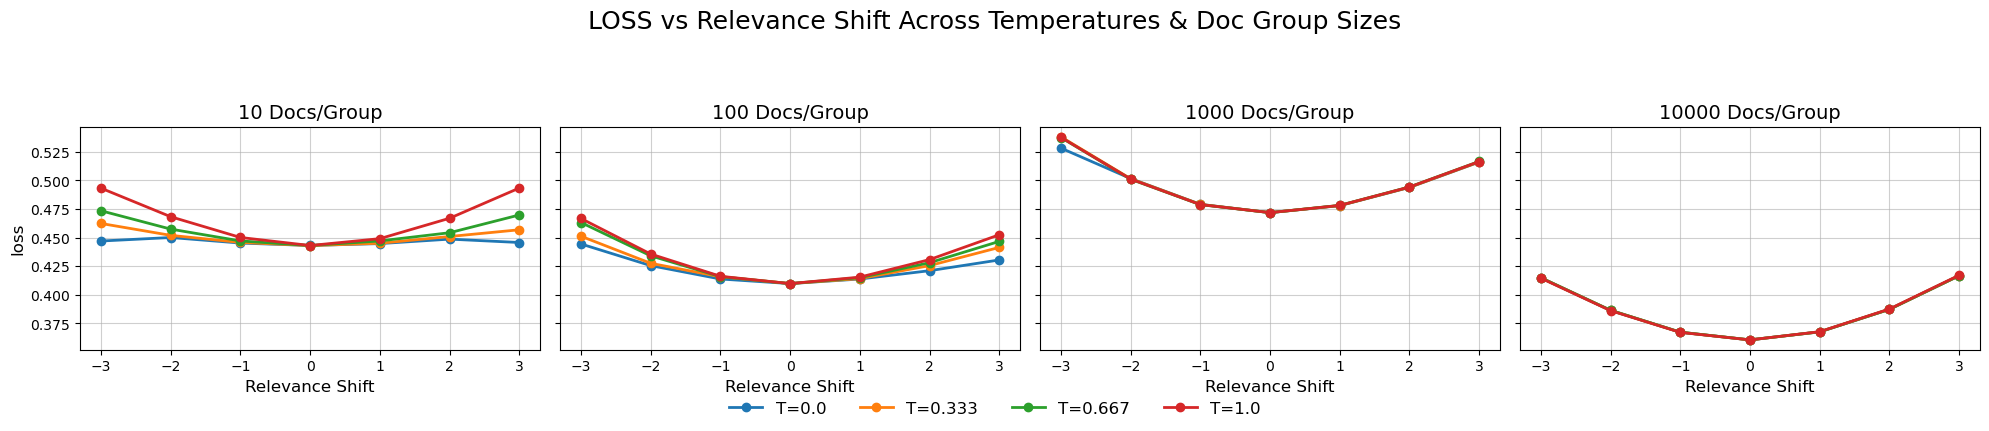

In [26]:
all_multi_relevance_dfs = [
    [multi_relevance_df_test_deep_10, multi_relevance_df_test_0333_deep_10, multi_relevance_df_test_0667_deep_10, multi_relevance_df_test_1_deep_10],
    [multi_relevance_df_test_deep_100, multi_relevance_df_test_0333_deep_100, multi_relevance_df_test_0667_deep_100, multi_relevance_df_test_1_deep_100],
    [multi_relevance_df_test_deep_1000, multi_relevance_df_test_0333_deep_1000, multi_relevance_df_test_0667_deep_1000, multi_relevance_df_test_1_deep_1000],
    [multi_relevance_df_test_deep_10000, multi_relevance_df_test_0333_deep_10000, multi_relevance_df_test_0667_deep_10000, multi_relevance_df_test_1_deep_10000]
]

all_multi_performance_dfs = [
    [multi_performance_df_test, multi_performance_df_test_0333, multi_performance_df_test_0667, multi_performance_df_test_1],
    [multi_performance_df_test_deep_100, multi_performance_df_test_0333_deep_100, multi_performance_df_test_0667_deep_100, multi_performance_df_test_1_deep_100],
    [multi_performance_df_test_deep_1000, multi_performance_df_test_0333_deep_1000, multi_performance_df_test_0667_deep_1000, multi_performance_df_test_1_deep_1000],
    [multi_performance_df_test_deep_10000, multi_performance_df_test_0333_deep_10000, multi_performance_df_test_0667_deep_10000, multi_performance_df_test_1_deep_10000]
]

temperatures = [0.0, 0.333, 0.667, 1.0]
doc_group_sizes = [10, 100, 1000, 10000]

# plot_mean_relevance_shift_combined(all_multi_relevance_dfs, temperatures, doc_group_sizes)
plot_performance_combined(all_multi_performance_dfs, temperatures, doc_group_sizes, metric='loss')


['relevance_param_shift_-3.0_idx0.csv', 'relevance_param_shift_1.0_idx0.csv', 'relevance_param_shift_-1.0_idx0.csv', 'relevance_param_shift_3.0_idx0.csv', 'relevance_param_shift_-2.0_idx0.csv', 'relevance_param_shift_0.0_idx0.csv', 'relevance_param_shift_2.0_idx0.csv']
['relevance_param_shift_-3.0_idx0.csv', 'relevance_param_shift_1.0_idx0.csv', 'relevance_param_shift_-1.0_idx0.csv', 'relevance_param_shift_3.0_idx0.csv', 'relevance_param_shift_-2.0_idx0.csv', 'relevance_param_shift_0.0_idx0.csv', 'relevance_param_shift_2.0_idx0.csv']
['relevance_param_shift_-3.0_idx0.csv', 'relevance_param_shift_1.0_idx0.csv', 'relevance_param_shift_-1.0_idx0.csv', 'relevance_param_shift_3.0_idx0.csv', 'relevance_param_shift_-2.0_idx0.csv', 'relevance_param_shift_0.0_idx0.csv', 'relevance_param_shift_2.0_idx0.csv']
['relevance_param_shift_-3.0_idx0.csv', 'relevance_param_shift_1.0_idx0.csv', 'relevance_param_shift_-1.0_idx0.csv', 'relevance_param_shift_3.0_idx0.csv', 'relevance_param_shift_-2.0_idx0.cs

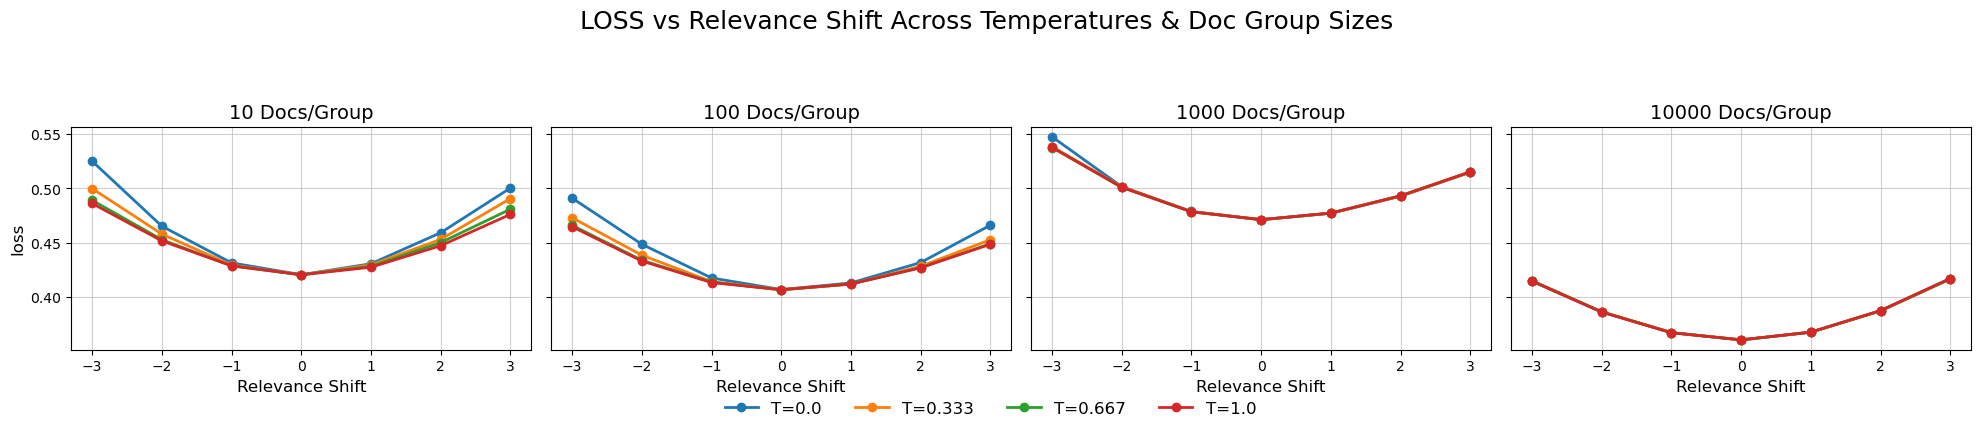

In [27]:
prefix = 'relevance_param_shift_'
folder_path_test_docs_10 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=10,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_0333_docs_10 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=10,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.333,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_0667_docs_10 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=10,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.667,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_1_10 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=10,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=1.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_docs_100 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=100,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_0333_docs_100 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=100,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.333,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_0667_docs_100 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=100,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.667,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_1_100 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=100,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=1.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0' 
folder_path_test_docs_1000 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=1000,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_0333_docs_1000 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=1000,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.333,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_0667_docs_1000 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=1000,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.667,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_1_1000 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=1000,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=1.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_docs_10000 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=10000,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_0333_docs_10000 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=10000,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.333,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_0667_docs_10000 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=10000,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.667,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_1_10000 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=10000,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=1.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'


multi_relevance_df_test_deep_10 = load_and_concat_multi_shift_files(folder_path_test_docs_10, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0333_deep_10 = load_and_concat_multi_shift_files(folder_path_test_0333_docs_10, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0667_deep_10 = load_and_concat_multi_shift_files(folder_path_test_0667_docs_10, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_1_deep_10 = load_and_concat_multi_shift_files(folder_path_test_1_10, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_deep_100 = load_and_concat_multi_shift_files(folder_path_test_docs_100, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0333_deep_100 = load_and_concat_multi_shift_files(folder_path_test_0333_docs_100, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0667_deep_100 = load_and_concat_multi_shift_files(folder_path_test_0667_docs_100, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_1_deep_100 = load_and_concat_multi_shift_files(folder_path_test_1_100, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_deep_1000 = load_and_concat_multi_shift_files(folder_path_test_docs_1000, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0333_deep_1000 = load_and_concat_multi_shift_files(folder_path_test_0333_docs_1000, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0667_deep_1000 = load_and_concat_multi_shift_files(folder_path_test_0667_docs_1000, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_1_deep_1000 = load_and_concat_multi_shift_files(folder_path_test_1_1000, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_deep_10000 = load_and_concat_multi_shift_files(folder_path_test_docs_10000, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0333_deep_10000 = load_and_concat_multi_shift_files(folder_path_test_0333_docs_10000, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0667_deep_10000 = load_and_concat_multi_shift_files(folder_path_test_0667_docs_10000, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_1_deep_10000 = load_and_concat_multi_shift_files(folder_path_test_1_10000, prefix, 'relevance_shift', 'param_idx')

# get performance df
prefix_performance_clicks = 'test_clicks_param_shift_'
prefix_performance_relevance = 'test_relevance_param_shift_'

multi_performance_df_test = load_and_concat_multi_shift_files(folder_path_test_docs_10, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0333 = load_and_concat_multi_shift_files(folder_path_test_0333_docs_10, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0667 = load_and_concat_multi_shift_files(folder_path_test_0667_docs_10, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_1 = load_and_concat_multi_shift_files(folder_path_test_1_10, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_deep_100 = load_and_concat_multi_shift_files(folder_path_test_docs_100, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0333_deep_100 = load_and_concat_multi_shift_files(folder_path_test_0333_docs_100, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0667_deep_100 = load_and_concat_multi_shift_files(folder_path_test_0667_docs_100, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_1_deep_100 = load_and_concat_multi_shift_files(folder_path_test_1_100, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_deep_1000 = load_and_concat_multi_shift_files(folder_path_test_docs_1000, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0333_deep_1000 = load_and_concat_multi_shift_files(folder_path_test_0333_docs_1000, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0667_deep_1000 = load_and_concat_multi_shift_files(folder_path_test_0667_docs_1000, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_1_deep_1000 = load_and_concat_multi_shift_files(folder_path_test_1_1000, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_deep_10000 = load_and_concat_multi_shift_files(folder_path_test_docs_10000, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0333_deep_10000 = load_and_concat_multi_shift_files(folder_path_test_0333_docs_10000, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0667_deep_10000 = load_and_concat_multi_shift_files(folder_path_test_0667_docs_10000, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_1_deep_10000 = load_and_concat_multi_shift_files(folder_path_test_1_10000, prefix_performance_clicks, 'relevance_shift', 'param_idx')

all_multi_relevance_dfs = [
    [multi_relevance_df_test_deep_10, multi_relevance_df_test_0333_deep_10, multi_relevance_df_test_0667_deep_10, multi_relevance_df_test_1_deep_10],
    [multi_relevance_df_test_deep_100, multi_relevance_df_test_0333_deep_100, multi_relevance_df_test_0667_deep_100, multi_relevance_df_test_1_deep_100],
    [multi_relevance_df_test_deep_1000, multi_relevance_df_test_0333_deep_1000, multi_relevance_df_test_0667_deep_1000, multi_relevance_df_test_1_deep_1000],
    [multi_relevance_df_test_deep_10000, multi_relevance_df_test_0333_deep_10000, multi_relevance_df_test_0667_deep_10000, multi_relevance_df_test_1_deep_10000]
]

all_multi_performance_dfs = [
    [multi_performance_df_test, multi_performance_df_test_0333, multi_performance_df_test_0667, multi_performance_df_test_1],
    [multi_performance_df_test_deep_100, multi_performance_df_test_0333_deep_100, multi_performance_df_test_0667_deep_100, multi_performance_df_test_1_deep_100],
    [multi_performance_df_test_deep_1000, multi_performance_df_test_0333_deep_1000, multi_performance_df_test_0667_deep_1000, multi_performance_df_test_1_deep_1000],
    [multi_performance_df_test_deep_10000, multi_performance_df_test_0333_deep_10000, multi_performance_df_test_0667_deep_10000, multi_performance_df_test_1_deep_10000]
]

temperatures = [0.0, 0.333, 0.667, 1.0]
doc_group_sizes = [10, 100, 1000, 10000]

# plot_mean_relevance_shift_combined(all_multi_relevance_dfs, temperatures, doc_group_sizes)
plot_performance_combined(all_multi_performance_dfs, temperatures, doc_group_sizes, metric='loss')


['relevance_param_shift_1.0_idx1.csv', 'relevance_param_shift_-3.0_idx1.csv', 'relevance_param_shift_-3.0_idx0.csv', 'relevance_param_shift_1.0_idx0.csv', 'relevance_param_shift_1.0_idx2.csv', 'relevance_param_shift_-3.0_idx2.csv', 'relevance_param_shift_-1.0_idx0.csv', 'relevance_param_shift_3.0_idx0.csv', 'relevance_param_shift_3.0_idx1.csv', 'relevance_param_shift_-1.0_idx1.csv', 'relevance_param_shift_3.0_idx2.csv', 'relevance_param_shift_-1.0_idx2.csv', 'relevance_param_shift_0.0_idx1.csv', 'relevance_param_shift_-2.0_idx1.csv', 'relevance_param_shift_-2.0_idx0.csv', 'relevance_param_shift_0.0_idx0.csv', 'relevance_param_shift_0.0_idx2.csv', 'relevance_param_shift_-2.0_idx2.csv', 'relevance_param_shift_2.0_idx0.csv', 'relevance_param_shift_2.0_idx1.csv', 'relevance_param_shift_2.0_idx2.csv']
['relevance_param_shift_1.0_idx1.csv', 'relevance_param_shift_-3.0_idx1.csv', 'relevance_param_shift_-3.0_idx0.csv', 'relevance_param_shift_1.0_idx0.csv', 'relevance_param_shift_1.0_idx2.csv',

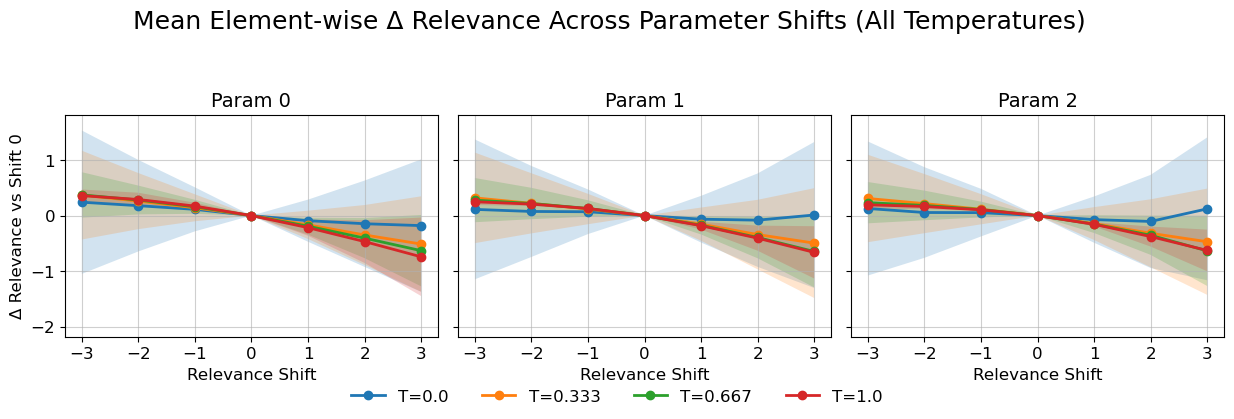

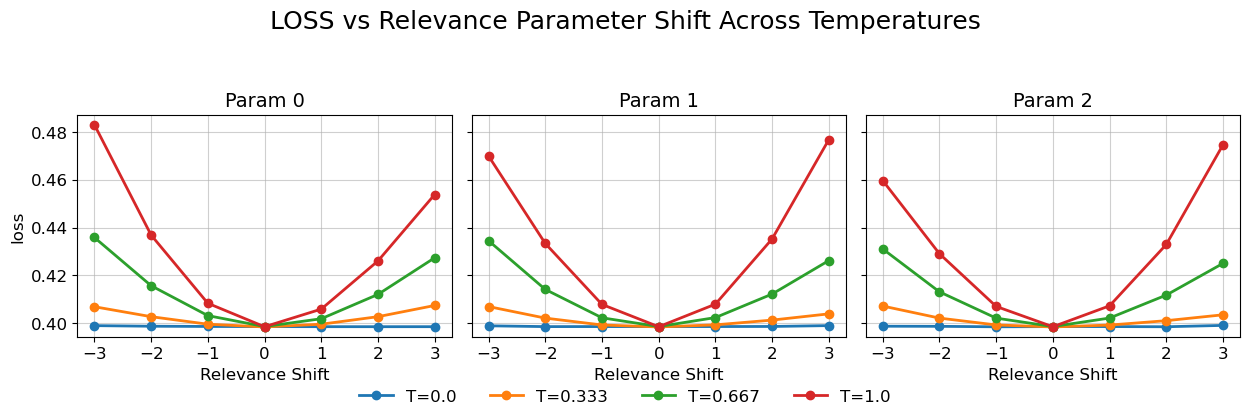

In [7]:
folder_path_test_deep = 'results/deterministic_custom_data/data=Custom_dataset,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_deep_0333 = 'results/deterministic_custom_data/data=Custom_dataset,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.333,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_deep_0667 = 'results/deterministic_custom_data/data=Custom_dataset,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.667,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_deep_1 = 'results/deterministic_custom_data/data=Custom_dataset,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=1.0,random_state=2021,relevance=deep,relevance_tower=deep'
multi_relevance_df_test_deep = load_and_concat_multi_shift_files(folder_path_test_deep, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_deep_0333 = load_and_concat_multi_shift_files(folder_path_test_deep_0333, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_deep_0667 = load_and_concat_multi_shift_files(folder_path_test_deep_0667, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_deep_1 = load_and_concat_multi_shift_files(folder_path_test_deep_1, prefix, 'relevance_shift', 'param_idx')
# get performance df
prefix_performance_clicks = 'test_clicks_param_shift_'
prefix_performance_relevance = 'test_relevance_param_shift_'
multi_performance_df_test_deep = load_and_concat_multi_shift_files(folder_path_test_deep, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_deep_0333 = load_and_concat_multi_shift_files(folder_path_test_deep_0333, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_deep_0667 = load_and_concat_multi_shift_files(folder_path_test_deep_0667, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_deep_1 = load_and_concat_multi_shift_files(folder_path_test_deep_1, prefix_performance_clicks, 'relevance_shift', 'param_idx') 

plot_mean_relevance_shift_all([multi_relevance_df_test_deep, multi_relevance_df_test_deep_0333, multi_relevance_df_test_deep_0667, multi_relevance_df_test_deep_1], [0.0, 0.333, 0.667, 1.0])
plot_performance_grid_all_temps([multi_performance_df_test_deep, multi_performance_df_test_deep_0333, multi_performance_df_test_deep_0667, multi_performance_df_test_deep_1], [0.0, 0.333, 0.667, 1.0], 'loss')

In [ ]:
folder_path_test_new_dataset_separation_docs_0_tmp_0 = 'results/test_deep/data=Custom_dataset_deep,experiment=test_deep,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_new_dataset_separation_docs_0333_tmp_0 = 'results/test_deep/data=Custom_dataset_deep,experiment=test_deep,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.333'
folder_path_test_new_dataset_separation_docs_0667_tmp_0 = 'results/test_deep/data=Custom_dataset_deep,experiment=test_deep,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.667'
folder_path_test_new_dataset_separation_docs_1_tmp_0 = 'results/test_deep/data=Custom_dataset_deep,experiment=test_deep,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=1.0'

folder_path_test_new_dataset_separation_docs_0_tmp_0333 = 'results/test_deep/data=Custom_dataset_deep,experiment=test_deep,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.333,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_new_dataset_separation_docs_0333_tmp_0333 = 'results/test_deep/data=Custom_dataset_deep,experiment=test_deep,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.333,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.333'
folder_path_test_new_dataset_separation_docs_0667_tmp_0333 = 'results/test_deep/data=Custom_dataset_deep,experiment=test_deep,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.333,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.667'  
folder_path_test_new_dataset_separation_docs_1_tmp_0333 = 'results/test_deep/data=Custom_dataset_deep,experiment=test_deep,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.333,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=1.0'

folder_path_test_new_dataset_separation_docs_0_tmp_0667 = 'results/test_deep/data=Custom_dataset_deep,experiment=test_deep,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.667,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_new_dataset_separation_docs_0333_tmp_0667 = 'results/test_deep/data=Custom_dataset_deep,experiment=test_deep,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.667,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.333'
folder_path_test_new_dataset_separation_docs_0667_tmp_0667 = 'results/test_deep/data=Custom_dataset_deep,experiment=test_deep,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.667,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.667'
folder_path_test_new_dataset_separation_docs_1_tmp_0667 = 'results/test_deep/data=Custom_dataset_deep,experiment=test_deep,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.667,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=1.0'

folder_path_test_new_dataset_separation_docs_0_tmp_1 = 'results/test_deep/data=Custom_dataset_deep,experiment=test_deep,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=1.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_new_dataset_separation_docs_0333_tmp_1 = 'results/test_deep/data=Custom_dataset_deep,experiment=test_deep,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=1.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.333'
folder_path_test_new_dataset_separation_docs_0667_tmp_1 = 'results/test_deep/data=Custom_dataset_deep,experiment=test_deep,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=1.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.667'
folder_path_test_new_dataset_separation_docs_1_tmp_1 = 'results/test_deep/data=Custom_dataset_deep,experiment=test_deep,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=1.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=1.0'

multi_relevance_df_test_new_dataset_separation_docs_0_tmp_0 = load_and_concat_multi_shift_files(folder_path_test_new_dataset_separation_docs_0_tmp_0, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_new_dataset_separation_docs_0333_tmp_0 = load_and_concat_multi_shift_files(folder_path_test_new_dataset_separation_docs_0333_tmp_0, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_new_dataset_separation_docs_0667_tmp_0 = load_and_concat_multi_shift_files(folder_path_test_new_dataset_separation_docs_0667_tmp_0, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_new_dataset_separation_docs_1_tmp_0 = load_and_concat_multi_shift_files(folder_path_test_new_dataset_separation_docs_1_tmp_0, prefix, 'relevance_shift', 'param_idx')

multi_relevance_df_test_new_dataset_separation_docs_0_tmp_0333 = load_and_concat_multi_shift_files(folder_path_test_new_dataset_separation_docs_0_tmp_0333, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_new_dataset_separation_docs_0333_tmp_0333 = load_and_concat_multi_shift_files(folder_path_test_new_dataset_separation_docs_0333_tmp_0333, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_new_dataset_separation_docs_0667_tmp_0333 = load_and_concat_multi_shift_files(folder_path_test_new_dataset_separation_docs_0667_tmp_0333, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_new_dataset_separation_docs_1_tmp_0333 = load_and_concat_multi_shift_files(folder_path_test_new_dataset_separation_docs_1_tmp_0333, prefix, 'relevance_shift', 'param_idx')

multi_relevance_df_test_new_dataset_separation_docs_0_tmp_0667 = load_and_concat_multi_shift_files(folder_path_test_new_dataset_separation_docs_0_tmp_0667, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_new_dataset_separation_docs_0333_tmp_0667 = load_and_concat_multi_shift_files(folder_path_test_new_dataset_separation_docs_0333_tmp_0667, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_new_dataset_separation_docs_0667_tmp_0667 = load_and_concat_multi_shift_files(folder_path_test_new_dataset_separation_docs_0667_tmp_0667, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_new_dataset_separation_docs_1_tmp_0667 = load_and_concat_multi_shift_files(folder_path_test_new_dataset_separation_docs_1_tmp_0667, prefix, 'relevance_shift', 'param_idx')

multi_relevance_df_test_new_dataset_separation_docs_0_tmp_1 = load_and_concat_multi_shift_files(folder_path_test_new_dataset_separation_docs_0_tmp_1, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_new_dataset_separation_docs_0333_tmp_1 = load_and_concat_multi_shift_files(folder_path_test_new_dataset_separation_docs_0333_tmp_1, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_new_dataset_separation_docs_0667_tmp_1 = load_and_concat_multi_shift_files(folder_path_test_new_dataset_separation_docs_0667_tmp_1, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_new_dataset_separation_docs_1_tmp_1 = load_and_concat_multi_shift_files(folder_path_test_new_dataset_separation_docs_1_tmp_1, prefix, 'relevance_shift', 'param_idx')
# get performance df
multi_performance_df_test_new_dataset_separation_docs_0_tmp_0 = load_and_concat_multi_shift_files(folder_path_test_new_dataset_separation_docs_0_tmp_0, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_new_dataset_separation_docs_0333_tmp_0 = load_and_concat_multi_shift_files(folder_path_test_new_dataset_separation_docs_0333_tmp_0, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_new_dataset_separation_docs_0667_tmp_0 = load_and_concat_multi_shift_files(folder_path_test_new_dataset_separation_docs_0667_tmp_0, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_new_dataset_separation_docs_1_tmp_0 = load_and_concat_multi_shift_files(folder_path_test_new_dataset_separation_docs_1_tmp_0, prefix_performance_clicks, 'relevance_shift', 'param_idx')

multi_performance_df_test_new_dataset_separation_docs_0_tmp_0333 = load_and_concat_multi_shift_files(folder_path_test_new_dataset_separation_docs_0_tmp_0333, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_new_dataset_separation_docs_0333_tmp_0333 = load_and_concat_multi_shift_files(folder_path_test_new_dataset_separation_docs_0333_tmp_0333, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_new_dataset_separation_docs_0667_tmp_0333 = load_and_concat_multi_shift_files(folder_path_test_new_dataset_separation_docs_0667_tmp_0333, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_new_dataset_separation_docs_1_tmp_0333 = load_and_concat_multi_shift_files(folder_path_test_new_dataset_separation_docs_1_tmp_0333, prefix_performance_clicks, 'relevance_shift', 'param_idx')

multi_performance_df_test_new_dataset_separation_docs_0_tmp_0667 = load_and_concat_multi_shift_files(folder_path_test_new_dataset_separation_docs_0_tmp_0667, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_new_dataset_separation_docs_0333_tmp_0667 = load_and_concat_multi_shift_files(folder_path_test_new_dataset_separation_docs_0333_tmp_0667, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_new_dataset_separation_docs_0667_tmp_0667 = load_and_concat_multi_shift_files(folder_path_test_new_dataset_separation_docs_0667_tmp_0667, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_new_dataset_separation_docs_1_tmp_0667 = load_and_concat_multi_shift_files(folder_path_test_new_dataset_separation_docs_1_tmp_0667, prefix_performance_clicks, 'relevance_shift', 'param_idx')

multi_performance_df_test_new_dataset_separation_docs_0_tmp_1 = load_and_concat_multi_shift_files(folder_path_test_new_dataset_separation_docs_0_tmp_1, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_new_dataset_separation_docs_0333_tmp_1 = load_and_concat_multi_shift_files(folder_path_test_new_dataset_separation_docs_0333_tmp_1, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_new_dataset_separation_docs_0667_tmp_1 = load_and_concat_multi_shift_files(folder_path_test_new_dataset_separation_docs_0667_tmp_1, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_new_dataset_separation_docs_1_tmp_1 = load_and_concat_multi_shift_files(folder_path_test_new_dataset_separation_docs_1_tmp_1, prefix_performance_clicks, 'relevance_shift', 'param_idx')

['relevance_param_shift_-3.0_idx0.csv', 'relevance_param_shift_1.0_idx0.csv', 'relevance_param_shift_3.0_idx0.csv', 'relevance_param_shift_-2.0_idx0.csv', 'relevance_param_shift_0.0_idx0.csv', 'relevance_param_shift_2.0_idx0.csv']
['relevance_param_shift_-3.0_idx0.csv', 'relevance_param_shift_1.0_idx0.csv', 'relevance_param_shift_3.0_idx0.csv', 'relevance_param_shift_-2.0_idx0.csv', 'relevance_param_shift_0.0_idx0.csv', 'relevance_param_shift_2.0_idx0.csv']
['relevance_param_shift_-3.0_idx0.csv', 'relevance_param_shift_1.0_idx0.csv', 'relevance_param_shift_3.0_idx0.csv', 'relevance_param_shift_-2.0_idx0.csv', 'relevance_param_shift_0.0_idx0.csv', 'relevance_param_shift_2.0_idx0.csv']
['relevance_param_shift_-3.0_idx0.csv', 'relevance_param_shift_1.0_idx0.csv', 'relevance_param_shift_3.0_idx0.csv', 'relevance_param_shift_-2.0_idx0.csv', 'relevance_param_shift_0.0_idx0.csv', 'relevance_param_shift_2.0_idx0.csv']
['relevance_param_shift_-3.0_idx0.csv', 'relevance_param_shift_1.0_idx0.csv'

/var/folders/nb/j_h4xjxd1tl7g7169hm8cdnc0000gn/T/ipykernel_12273/1190765910.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(temperatures))


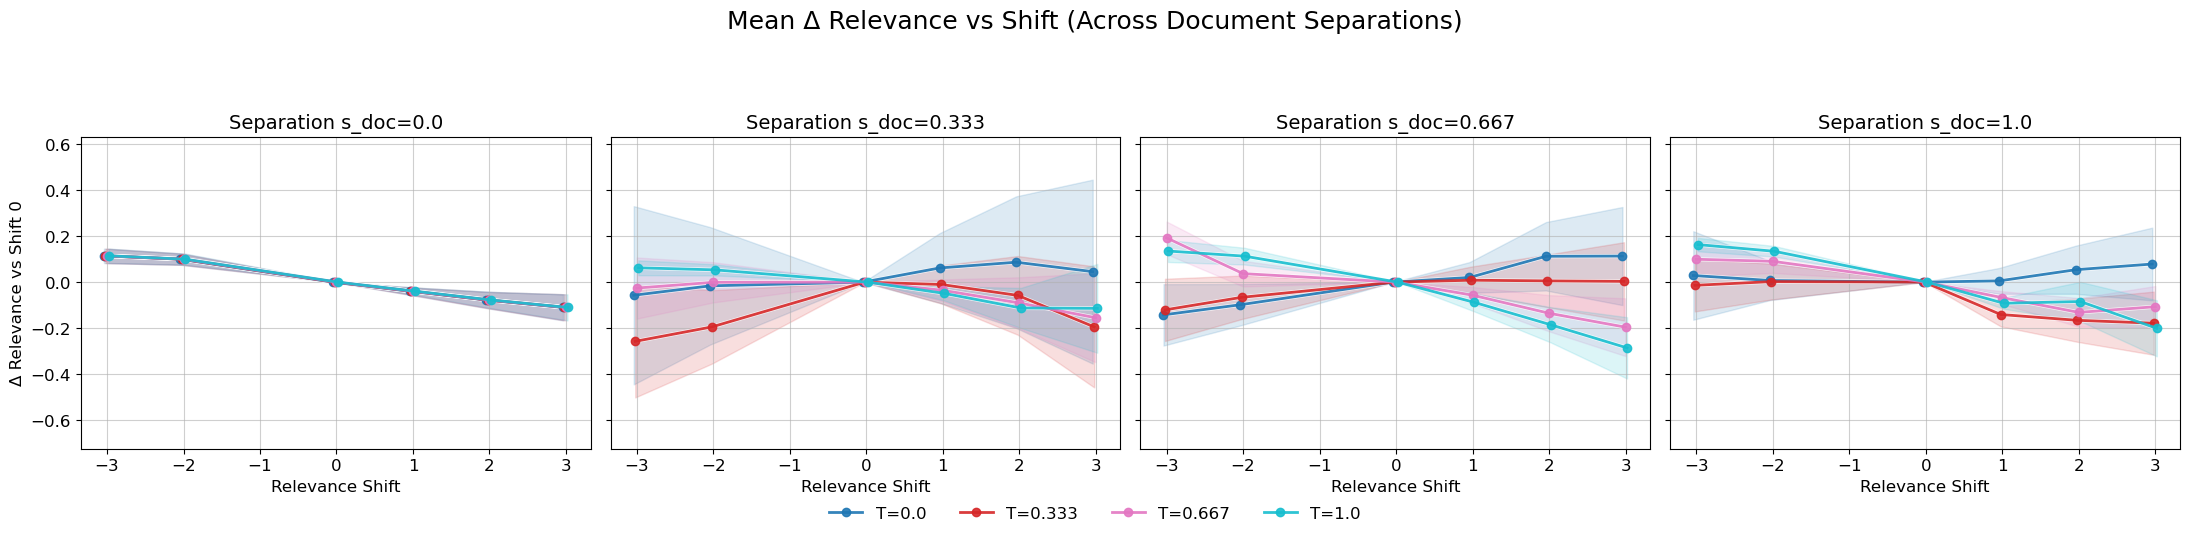

/var/folders/nb/j_h4xjxd1tl7g7169hm8cdnc0000gn/T/ipykernel_12273/1190765910.py:85: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(temperatures))


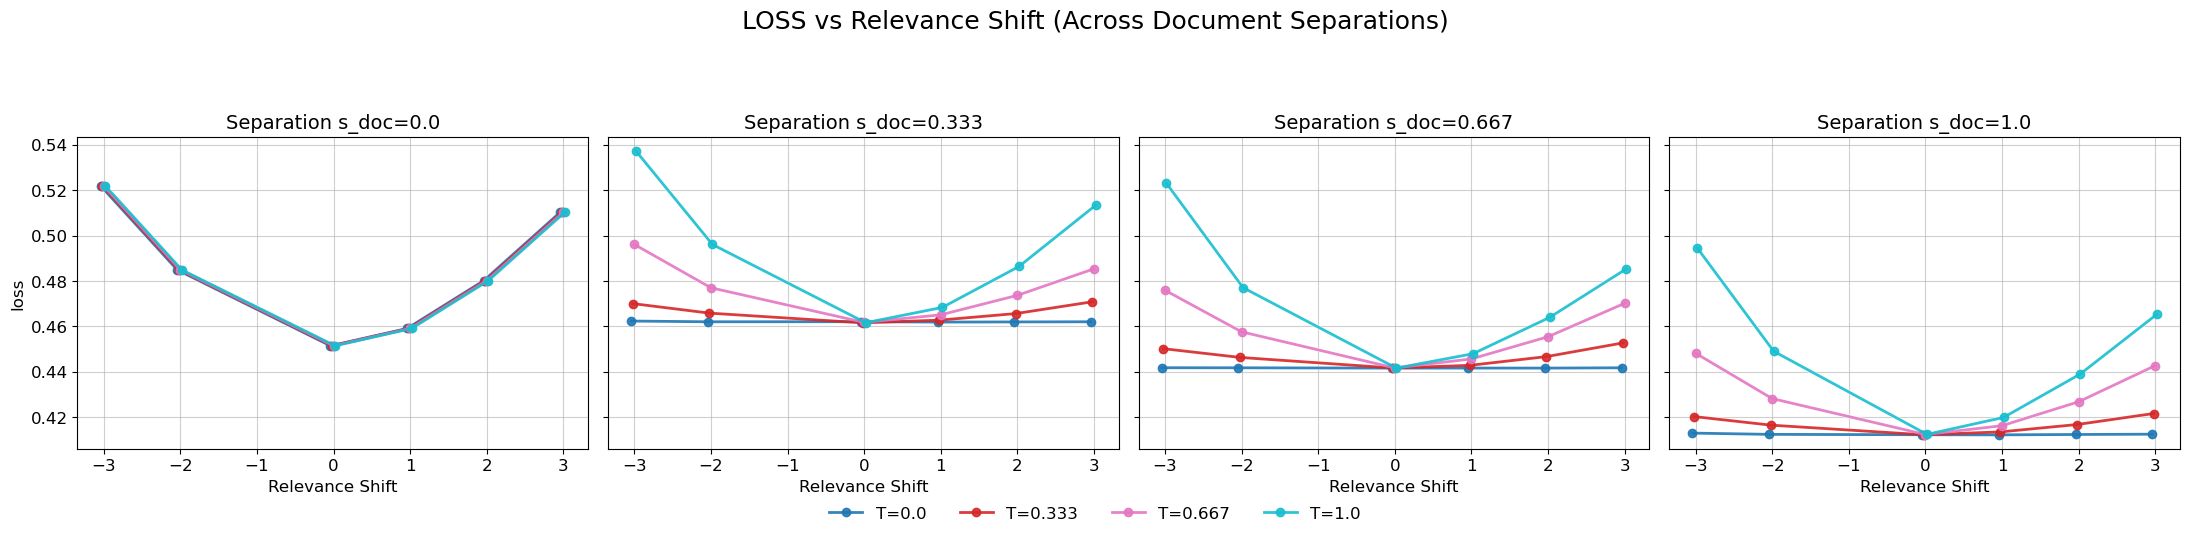

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.lines as mlines


def plot_mean_relevance_shift_by_separation(multi_relevance_dfs_groups, separations, temperatures):
    """
    Plot mean Δ relevance vs shift for each document separation (s_doc) in a row.
    Adds a small horizontal jitter so overlapping lines become visible.
    """
    n_sep = len(separations)
    fig, axes = plt.subplots(1, n_sep, figsize=(5.5 * n_sep, 5), sharey=True)
    axes = np.array(axes).flatten()

    cmap = plt.cm.get_cmap('tab10', len(temperatures))
    colors = [cmap(i) for i in range(len(temperatures))]

    jitter_strength = 0.02  # small horizontal offset factor

    all_means, all_stds = [], []

    for i, (dfs, sep, ax) in enumerate(zip(multi_relevance_dfs_groups, separations, axes)):
        for j, (df, temp, color) in enumerate(zip(dfs, temperatures, colors)):
            subset = df[df['param_idx'] == 0]
            if subset.empty:
                continue

            baseline = subset[subset['relevance_shift'] == 0]['relevance'].reset_index(drop=True)
            diff_df = pd.DataFrame()

            for shift in sorted(subset['relevance_shift'].unique()):
                values = subset[subset['relevance_shift'] == shift]['relevance'].reset_index(drop=True)
                diff_df[shift] = values - baseline

            means = diff_df.mean()
            stds = diff_df.std()

            # Add horizontal jitter so lines don't fully overlap
            jitter = (j - len(temperatures) / 2) * jitter_strength
            x_vals = np.array(means.index, dtype=float) + jitter

            # Draw std fill
            ax.fill_between(x_vals, means - stds, means + stds, color=color, alpha=0.15, zorder=1)

            # White outline for contrast
            ax.plot(x_vals, means.values, color='white', linewidth=3, alpha=0.8, zorder=2)
            ax.plot(x_vals, means.values, color=color, marker='o', linewidth=2,
                    alpha=0.9, label=f"T={temp}", zorder=3)

            all_means.extend(means.values)
            all_stds.extend(stds.values)

        ax.set_title(f"Separation s_doc={sep}", fontsize=14)
        ax.grid(True, alpha=0.6, zorder=0)
        ax.tick_params(axis='both', labelsize=12)
        if i == 0:
            ax.set_ylabel('Δ Relevance vs Shift 0', fontsize=12)
        ax.set_xlabel('Relevance Shift', fontsize=12)

    if all_means and all_stds:
        ymin = min(all_means) - max(all_stds) * 1.1
        ymax = max(all_means) + max(all_stds) * 1.1
        for ax in axes:
            ax.set_ylim(ymin, ymax)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(temperatures),
               frameon=False, fontsize=12)
    fig.suptitle('Mean Δ Relevance vs Shift (Across Document Separations)',
                 fontsize=18, y=1.05)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


def plot_performance_by_separation(multi_performance_dfs_groups, separations, temperatures, metric='loss'):
    """
    Plot performance metric vs relevance shift for each document separation (s_doc) in a row.
    Adds horizontal jitter to make overlapping lines visible.
    """
    n_sep = len(separations)
    fig, axes = plt.subplots(1, n_sep, figsize=(5.5 * n_sep, 5), sharey=True)
    axes = np.array(axes).flatten()

    cmap = plt.cm.get_cmap('tab10', len(temperatures))
    colors = [cmap(i) for i in range(len(temperatures))]

    jitter_strength = 0.02

    for i, (dfs, sep, ax) in enumerate(zip(multi_performance_dfs_groups, separations, axes)):
        for j, (df, temp, color) in enumerate(zip(dfs, temperatures, colors)):
            subset = df[df['param_idx'] == 0]
            if subset.empty:
                continue

            x = np.array(subset['relevance_shift'], dtype=float)
            y = subset[metric]

            # Apply same horizontal jitter
            x_jittered = x + (j - len(temperatures) / 2) * jitter_strength

            ax.plot(x_jittered, y, color='white', linewidth=3, alpha=0.8, zorder=2)
            ax.plot(x_jittered, y, color=color, marker='o', linewidth=2, alpha=0.9,
                    label=f"T={temp}", zorder=3)

        ax.set_title(f"Separation s_doc={sep}", fontsize=14)
        ax.grid(True, alpha=0.6, zorder=0)
        ax.tick_params(axis='both', labelsize=12)
        if i == 0:
            ax.set_ylabel(metric, fontsize=12)
        ax.set_xlabel('Relevance Shift', fontsize=12)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(temperatures),
               frameon=False, fontsize=12)
    fig.suptitle(f'{metric.upper()} vs Relevance Shift (Across Document Separations)',
                 fontsize=18, y=1.05)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


separations = [0.0, 0.333, 0.667, 1.0]
temperatures = [0.0, 0.333, 0.667, 1.0]

# Group relevance dfs by separation
multi_relevance_groups = [
    [multi_relevance_df_test_new_dataset_separation_docs_0_tmp_0,
     multi_relevance_df_test_new_dataset_separation_docs_0_tmp_0333,
     multi_relevance_df_test_new_dataset_separation_docs_0_tmp_0667,
     multi_relevance_df_test_new_dataset_separation_docs_0_tmp_1],
    [multi_relevance_df_test_new_dataset_separation_docs_0333_tmp_0,
     multi_relevance_df_test_new_dataset_separation_docs_0333_tmp_0333,
     multi_relevance_df_test_new_dataset_separation_docs_0333_tmp_0667,
     multi_relevance_df_test_new_dataset_separation_docs_0333_tmp_1],
    [multi_relevance_df_test_new_dataset_separation_docs_0667_tmp_0,
     multi_relevance_df_test_new_dataset_separation_docs_0667_tmp_0333,
     multi_relevance_df_test_new_dataset_separation_docs_0667_tmp_0667,
     multi_relevance_df_test_new_dataset_separation_docs_0667_tmp_1],
    [multi_relevance_df_test_new_dataset_separation_docs_1_tmp_0,
     multi_relevance_df_test_new_dataset_separation_docs_1_tmp_0333,
     multi_relevance_df_test_new_dataset_separation_docs_1_tmp_0667,
     multi_relevance_df_test_new_dataset_separation_docs_1_tmp_1]
]

# Same for performance
multi_performance_groups = [
    [multi_performance_df_test_new_dataset_separation_docs_0_tmp_0,
     multi_performance_df_test_new_dataset_separation_docs_0_tmp_0333,
     multi_performance_df_test_new_dataset_separation_docs_0_tmp_0667,
     multi_performance_df_test_new_dataset_separation_docs_0_tmp_1],
    [multi_performance_df_test_new_dataset_separation_docs_0333_tmp_0,
     multi_performance_df_test_new_dataset_separation_docs_0333_tmp_0333,
     multi_performance_df_test_new_dataset_separation_docs_0333_tmp_0667,
     multi_performance_df_test_new_dataset_separation_docs_0333_tmp_1],
    [multi_performance_df_test_new_dataset_separation_docs_0667_tmp_0,
     multi_performance_df_test_new_dataset_separation_docs_0667_tmp_0333,
     multi_performance_df_test_new_dataset_separation_docs_0667_tmp_0667,
     multi_performance_df_test_new_dataset_separation_docs_0667_tmp_1],
    [multi_performance_df_test_new_dataset_separation_docs_1_tmp_0,
     multi_performance_df_test_new_dataset_separation_docs_1_tmp_0333,
     multi_performance_df_test_new_dataset_separation_docs_1_tmp_0667,
     multi_performance_df_test_new_dataset_separation_docs_1_tmp_1]
]

# Plot side-by-side comparisons
plot_mean_relevance_shift_by_separation(multi_relevance_groups, separations, temperatures)
plot_performance_by_separation(multi_performance_groups, separations, temperatures, metric='loss')


['relevance_param_shift_-3.0_idx0.csv', 'relevance_param_shift_1.0_idx0.csv', 'relevance_param_shift_3.0_idx0.csv', 'relevance_param_shift_-2.0_idx0.csv', 'relevance_param_shift_0.0_idx0.csv', 'relevance_param_shift_2.0_idx0.csv']
['relevance_param_shift_-3.0_idx0.csv', 'relevance_param_shift_1.0_idx0.csv', 'relevance_param_shift_3.0_idx0.csv', 'relevance_param_shift_-2.0_idx0.csv', 'relevance_param_shift_0.0_idx0.csv', 'relevance_param_shift_2.0_idx0.csv']
['relevance_param_shift_-3.0_idx0.csv', 'relevance_param_shift_1.0_idx0.csv', 'relevance_param_shift_3.0_idx0.csv', 'relevance_param_shift_-2.0_idx0.csv', 'relevance_param_shift_0.0_idx0.csv', 'relevance_param_shift_2.0_idx0.csv']
['relevance_param_shift_-3.0_idx0.csv', 'relevance_param_shift_1.0_idx0.csv', 'relevance_param_shift_3.0_idx0.csv', 'relevance_param_shift_-2.0_idx0.csv', 'relevance_param_shift_0.0_idx0.csv', 'relevance_param_shift_2.0_idx0.csv']
['test_clicks_param_shift_0.0_idx0.csv', 'test_clicks_param_shift_2.0_idx0.c

/var/folders/nb/j_h4xjxd1tl7g7169hm8cdnc0000gn/T/ipykernel_12273/1190765910.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(temperatures))


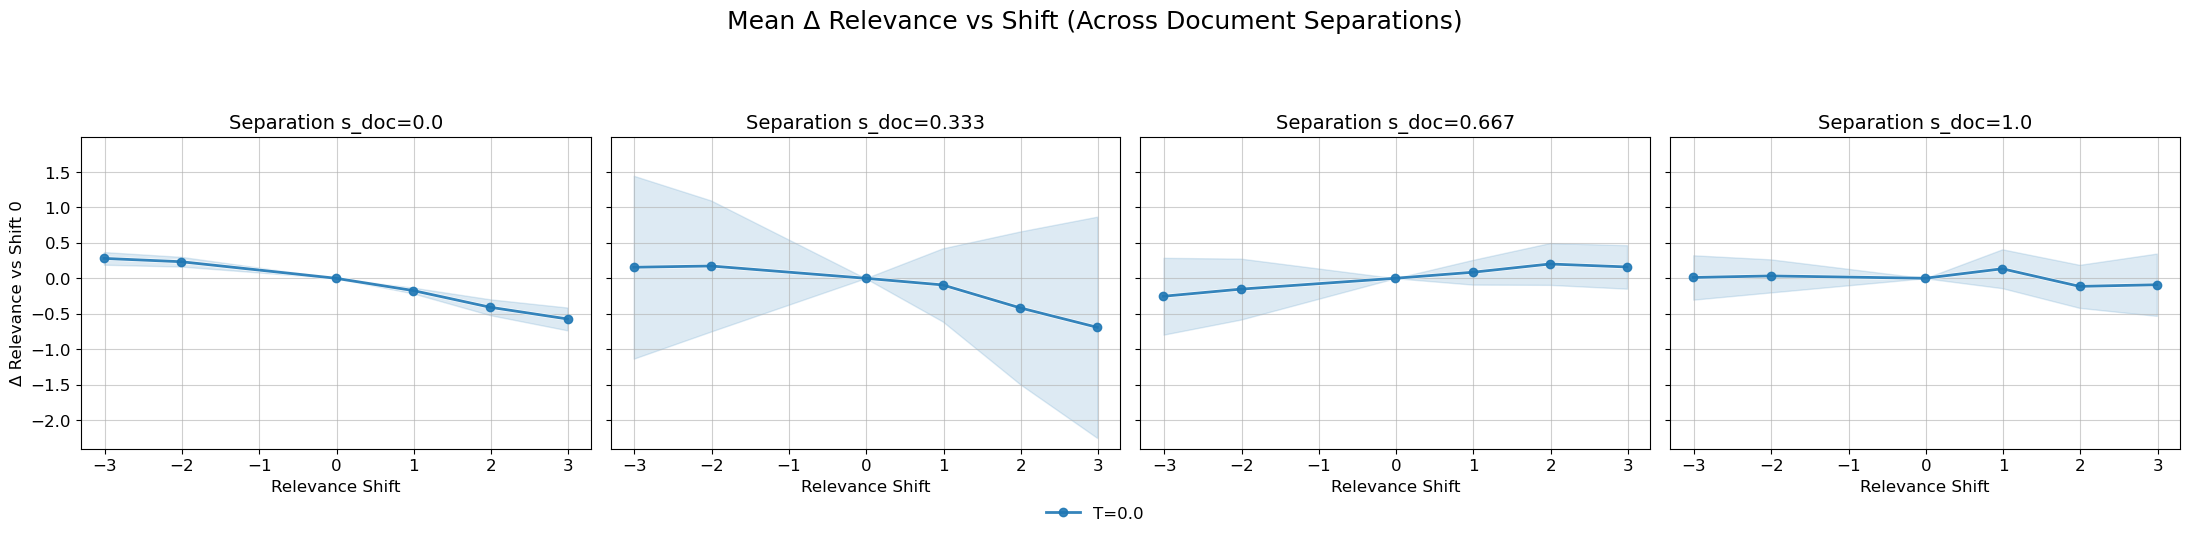

/var/folders/nb/j_h4xjxd1tl7g7169hm8cdnc0000gn/T/ipykernel_12273/1190765910.py:85: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(temperatures))


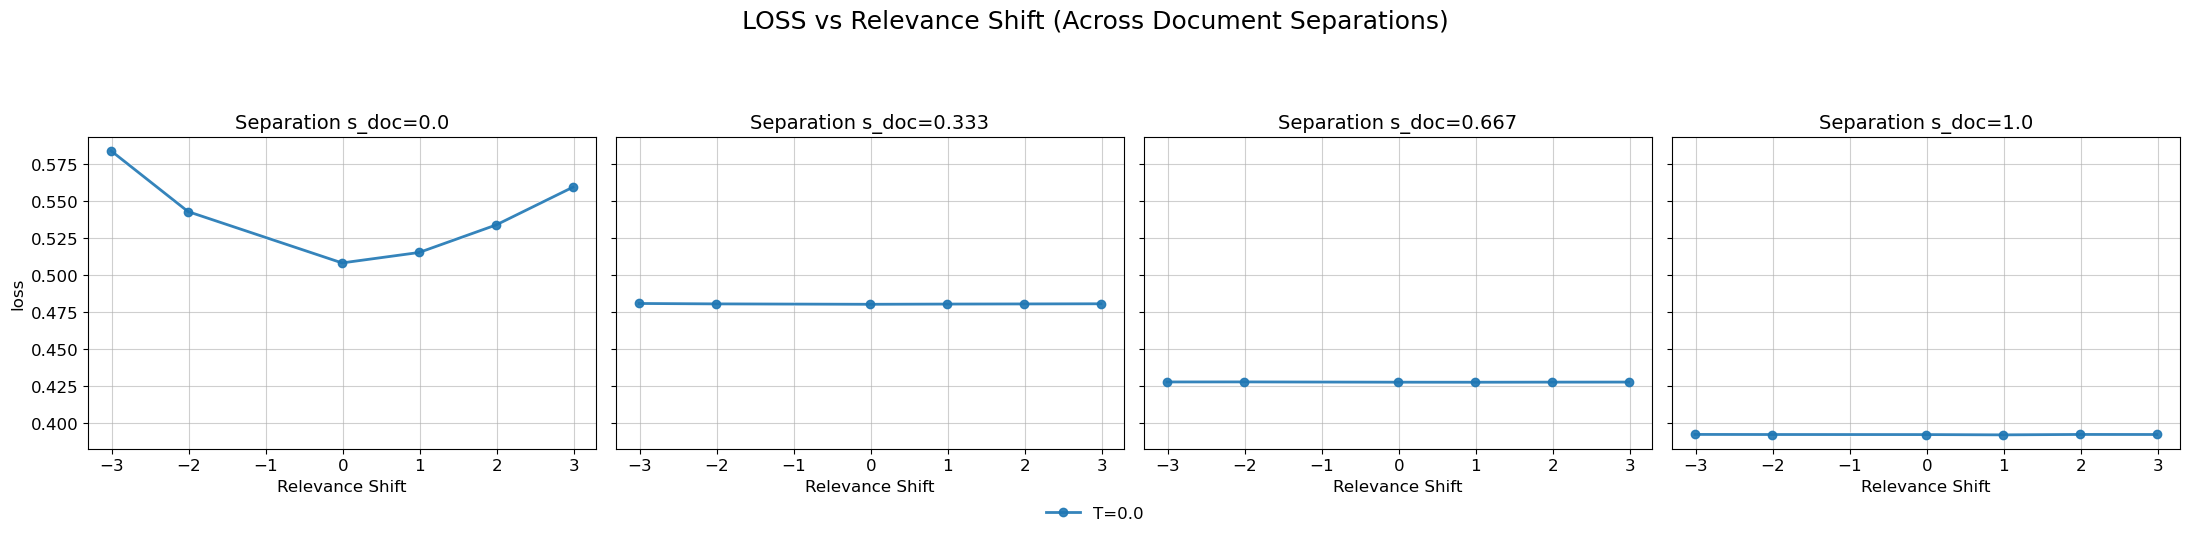

In [9]:
folder_path_test_low_dimensional_separation_docs_0_tmp_0 = 'results/test_deep_low_dimensional_data/data=Custom_dataset_deep,experiment=test_deep_low_dimensional_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_low_dimensional_separation_docs_0333_tmp_0 = 'results/test_deep_low_dimensional_data/data=Custom_dataset_deep,experiment=test_deep_low_dimensional_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.333'
folder_path_test_low_dimensional_separation_docs_0667_tmp_0 = 'results/test_deep_low_dimensional_data/data=Custom_dataset_deep,experiment=test_deep_low_dimensional_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.667'
folder_path_test_low_dimensional_separation_docs_1_tmp_0 = 'results/test_deep_low_dimensional_data/data=Custom_dataset_deep,experiment=test_deep_low_dimensional_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=1.0'


multi_relevance_df_test_low_dimensional_separation_docs_0_tmp_0 = load_and_concat_multi_shift_files(folder_path_test_low_dimensional_separation_docs_0_tmp_0, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_low_dimensional_separation_docs_0333_tmp_0 = load_and_concat_multi_shift_files(folder_path_test_low_dimensional_separation_docs_0333_tmp_0, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_low_dimensional_separation_docs_0667_tmp_0 = load_and_concat_multi_shift_files(folder_path_test_low_dimensional_separation_docs_0667_tmp_0, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_low_dimensional_separation_docs_1_tmp_0 = load_and_concat_multi_shift_files(folder_path_test_low_dimensional_separation_docs_1_tmp_0, prefix, 'relevance_shift', 'param_idx')

# get performance df
multi_performance_df_test_low_dimensional_separation_docs_0_tmp_0 = load_and_concat_multi_shift_files(folder_path_test_low_dimensional_separation_docs_0_tmp_0, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_low_dimensional_separation_docs_0333_tmp_0 = load_and_concat_multi_shift_files(folder_path_test_low_dimensional_separation_docs_0333_tmp_0, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_low_dimensional_separation_docs_0667_tmp_0 = load_and_concat_multi_shift_files(folder_path_test_low_dimensional_separation_docs_0667_tmp_0, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_low_dimensional_separation_docs_1_tmp_0 = load_and_concat_multi_shift_files(folder_path_test_low_dimensional_separation_docs_1_tmp_0, prefix_performance_clicks, 'relevance_shift', 'param_idx')

# Only tmp_0 files exist
multi_relevance_groups = [
    [multi_relevance_df_test_low_dimensional_separation_docs_0_tmp_0],
    [multi_relevance_df_test_low_dimensional_separation_docs_0333_tmp_0],
    [multi_relevance_df_test_low_dimensional_separation_docs_0667_tmp_0],
    [multi_relevance_df_test_low_dimensional_separation_docs_1_tmp_0]
]

multi_performance_groups = [
    [multi_performance_df_test_low_dimensional_separation_docs_0_tmp_0],
    [multi_performance_df_test_low_dimensional_separation_docs_0333_tmp_0],
    [multi_performance_df_test_low_dimensional_separation_docs_0667_tmp_0],
    [multi_performance_df_test_low_dimensional_separation_docs_1_tmp_0]
]

# Adjust temperatures to match your available tmp_0 files
temperatures = [0.0]  # only tmp_0

separations = [0.0, 0.333, 0.667, 1.0]

# Plot mean Δ relevance vs shift
plot_mean_relevance_shift_by_separation(multi_relevance_groups, separations, temperatures)

# Plot performance metric vs shift
plot_performance_by_separation(multi_performance_groups, separations, temperatures, metric='loss')


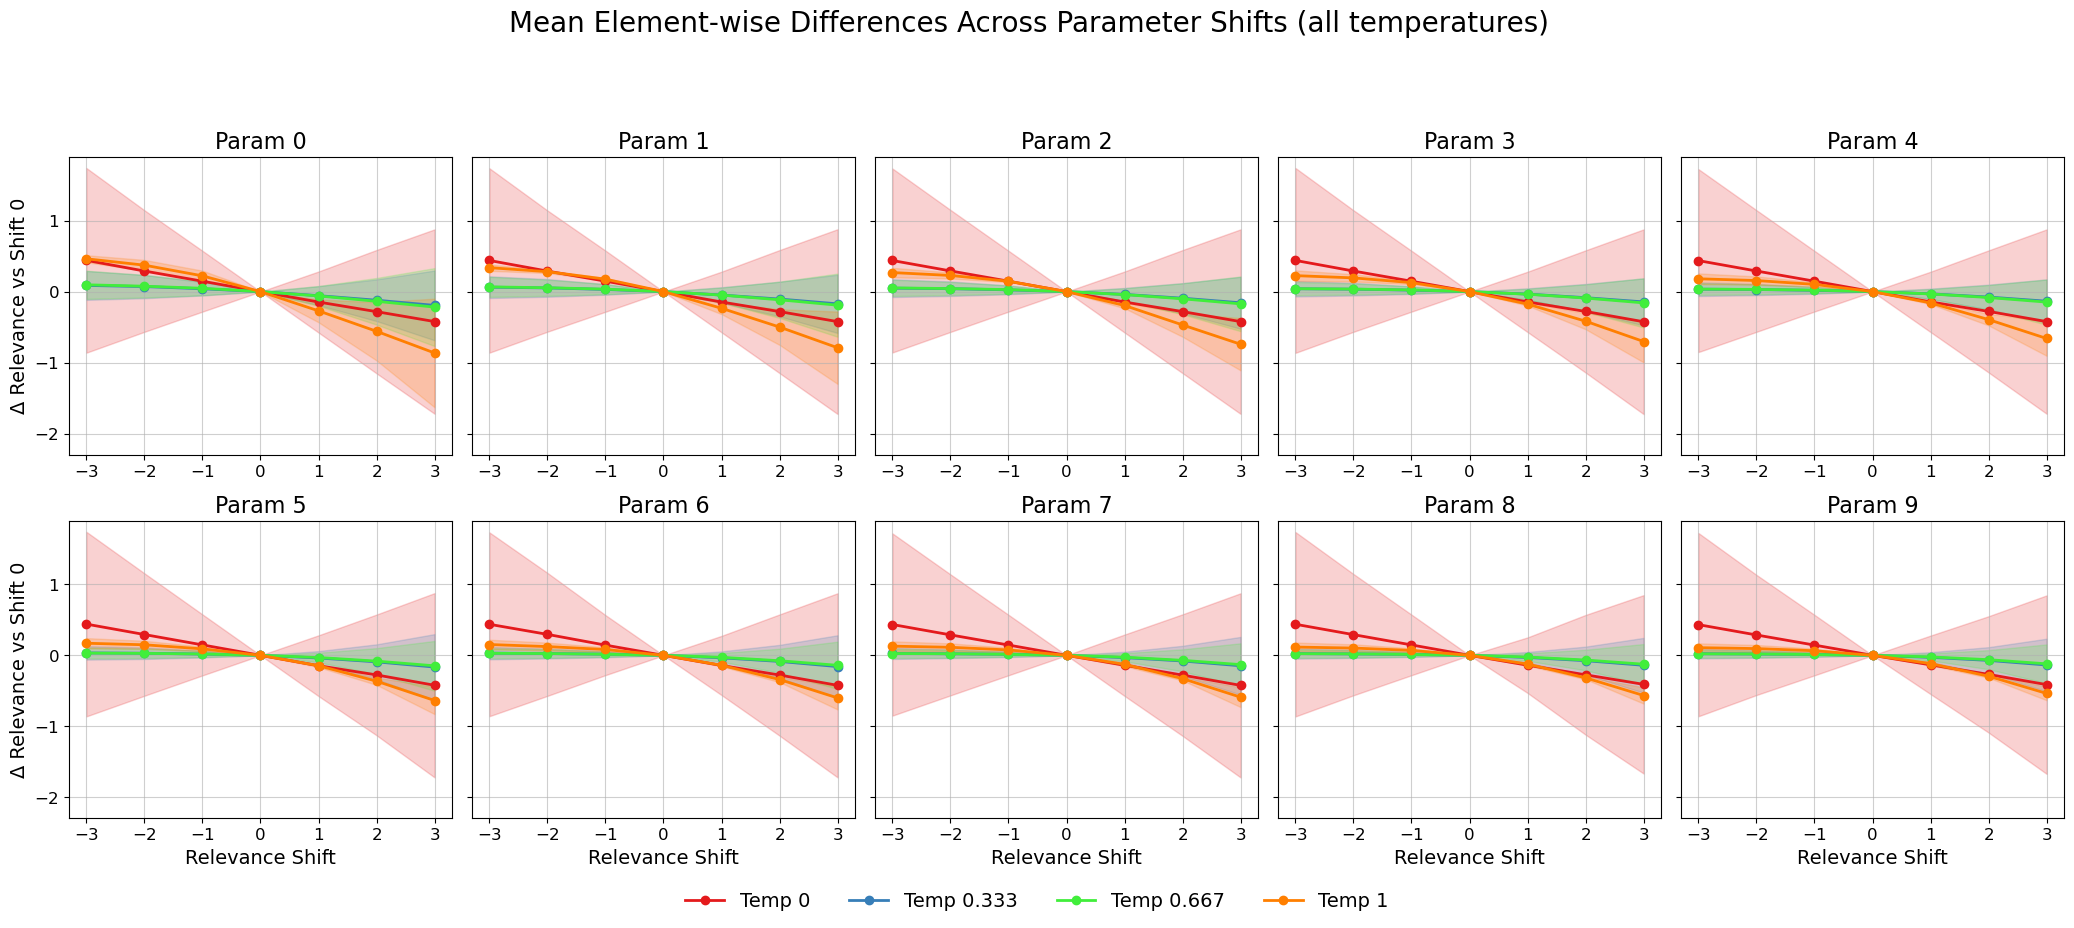

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_mean_relevance_shift_all(multi_relevance_dfs, temperatures):
    fig, axes = plt.subplots(2, 5, figsize=(21, 9), sharey=True)
    axes = axes.flatten()

    # Highly distinctive colors
    colors = ['#e41a1c', '#377eb8', "#41ee3b", '#ff7f00']  # red, blue, green, orange
    all_means, all_stds = [], []

    for idx in range(10):
        ax = axes[idx]

        # First plot all fill_between in order of temperatures (for layering)
        for df, temp, color in zip(multi_relevance_dfs, temperatures, colors):
            subset = df[df['param_idx'] == idx]
            baseline = subset[subset['relevance_shift'] == 0]['relevance'].reset_index(drop=True)

            diff_df = pd.DataFrame()
            for shift in sorted(subset['relevance_shift'].unique()):
                values = subset[subset['relevance_shift'] == shift]['relevance'].reset_index(drop=True)
                diff_df[shift] = values - baseline

            means = diff_df.mean()
            stds = diff_df.std()

            ax.fill_between(means.index, means - stds, means + stds,
                            color=color, alpha=0.2, zorder=1)  # lower zorder for fills

            all_means.extend(means.values)
            all_stds.extend(stds.values)

        # Then plot the lines on top
        for df, temp, color in zip(multi_relevance_dfs, temperatures, colors):
            subset = df[df['param_idx'] == idx]
            baseline = subset[subset['relevance_shift'] == 0]['relevance'].reset_index(drop=True)

            diff_df = pd.DataFrame()
            for shift in sorted(subset['relevance_shift'].unique()):
                values = subset[subset['relevance_shift'] == shift]['relevance'].reset_index(drop=True)
                diff_df[shift] = values - baseline

            means = diff_df.mean()

            ax.plot(means.index, means.values, marker='o', linewidth=2, 
                    label=f'Temp {temp}', color=color, zorder=2)  # higher zorder for lines

        ax.set_title(f'Param {idx}', fontsize=16)
        ax.tick_params(axis='both', labelsize=12)
        ax.grid(True, alpha=0.6)

        if idx % 5 == 0:
            ax.set_ylabel('Δ Relevance vs Shift 0', fontsize=14)
        if idx >= 5:
            ax.set_xlabel('Relevance Shift', fontsize=14)

    # Global y-limits
    ymin = min(all_means) - max(all_stds) * 1.1
    ymax = max(all_means) + max(all_stds) * 1.1
    for ax in axes:
        ax.set_ylim(ymin, ymax)

    # Global title
    fig.suptitle('Mean Element-wise Differences Across Parameter Shifts (all temperatures)',
                 fontsize=20, y=1.02)

    # Legend below
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', fontsize=14, ncol=4, frameon=False)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

# Example call
plot_mean_relevance_shift_all(
    [multi_relevance_df_tmp_0, multi_relevance_df_tmp_0333, multi_relevance_df_tmp_0667, multi_relevance_df_tmp_1],
    [0, 0.333, 0.667, 1]
)

In [7]:
plot_mean_relevance_shift_all(
    [multi_relevance_df_deep_0, multi_relevance_df_deep_0333, multi_relevance_df_deep_0667, multi_relevance_df_deep_1],
    [0, 0.333, 0.667, 1]
)

NameError: name 'np' is not defined

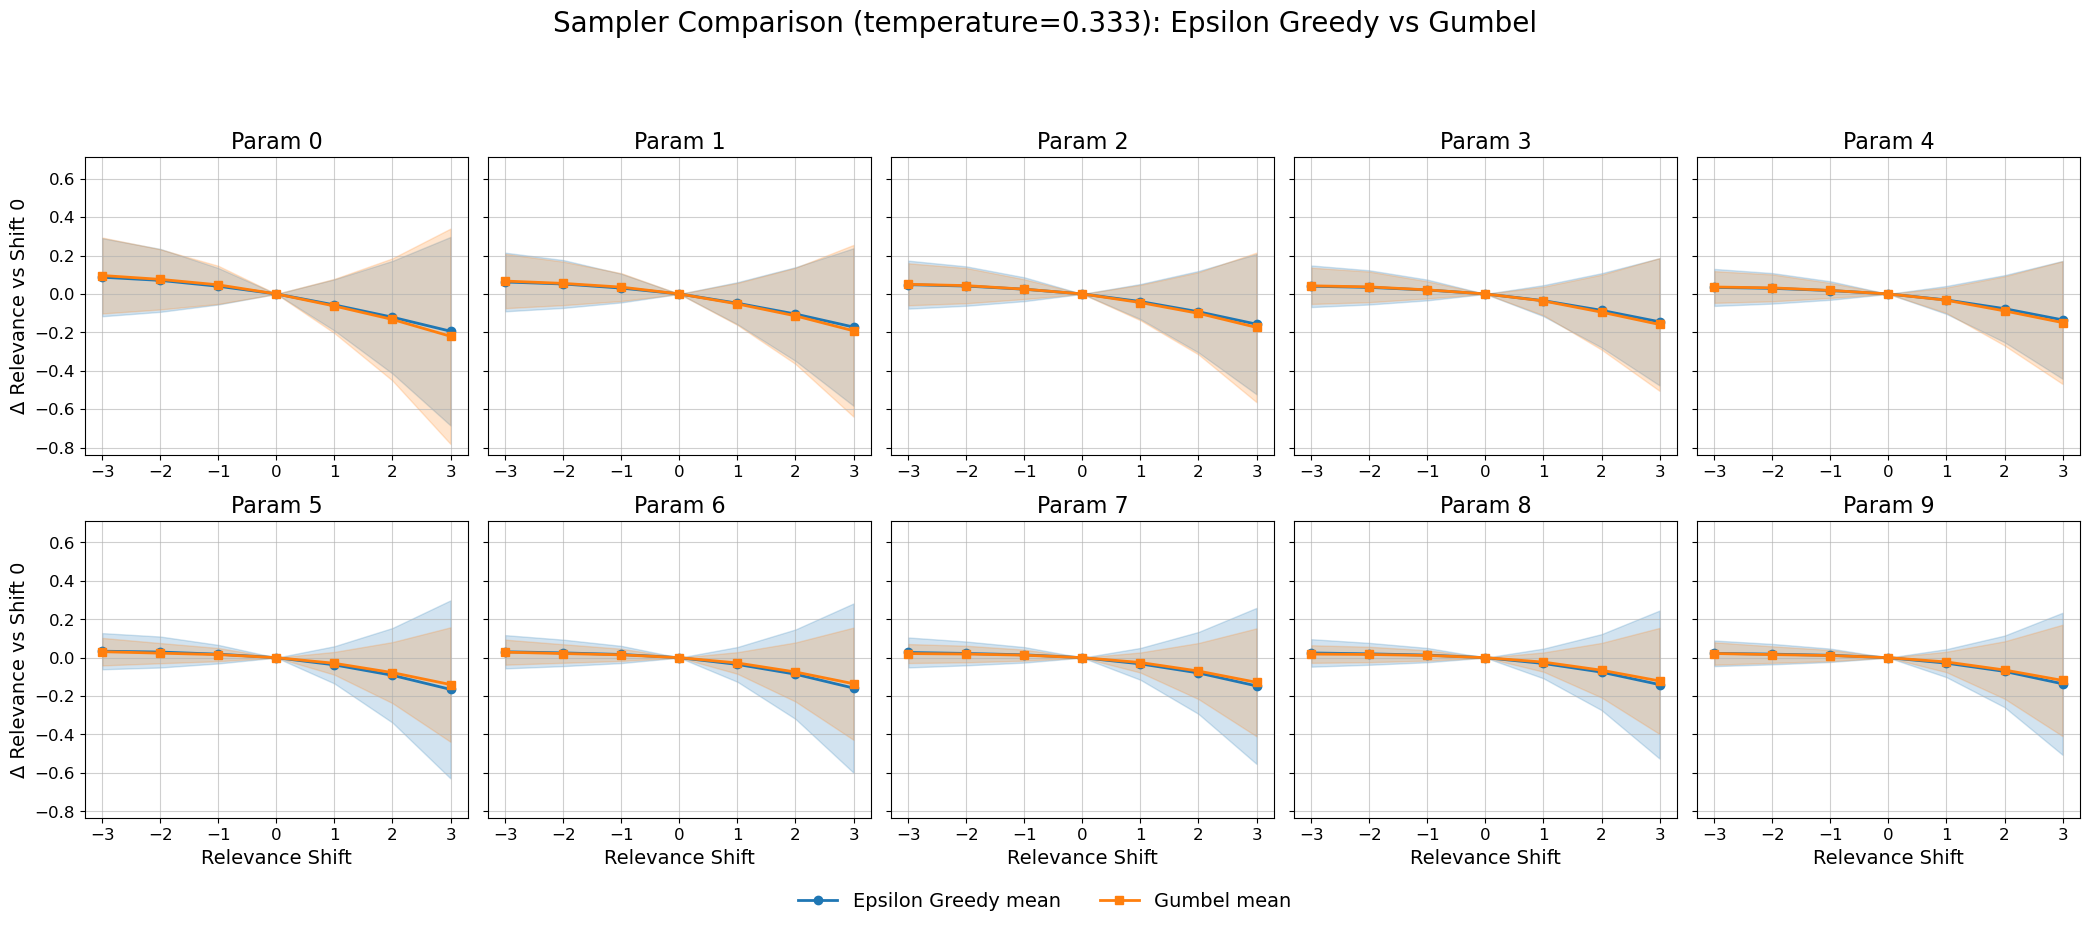

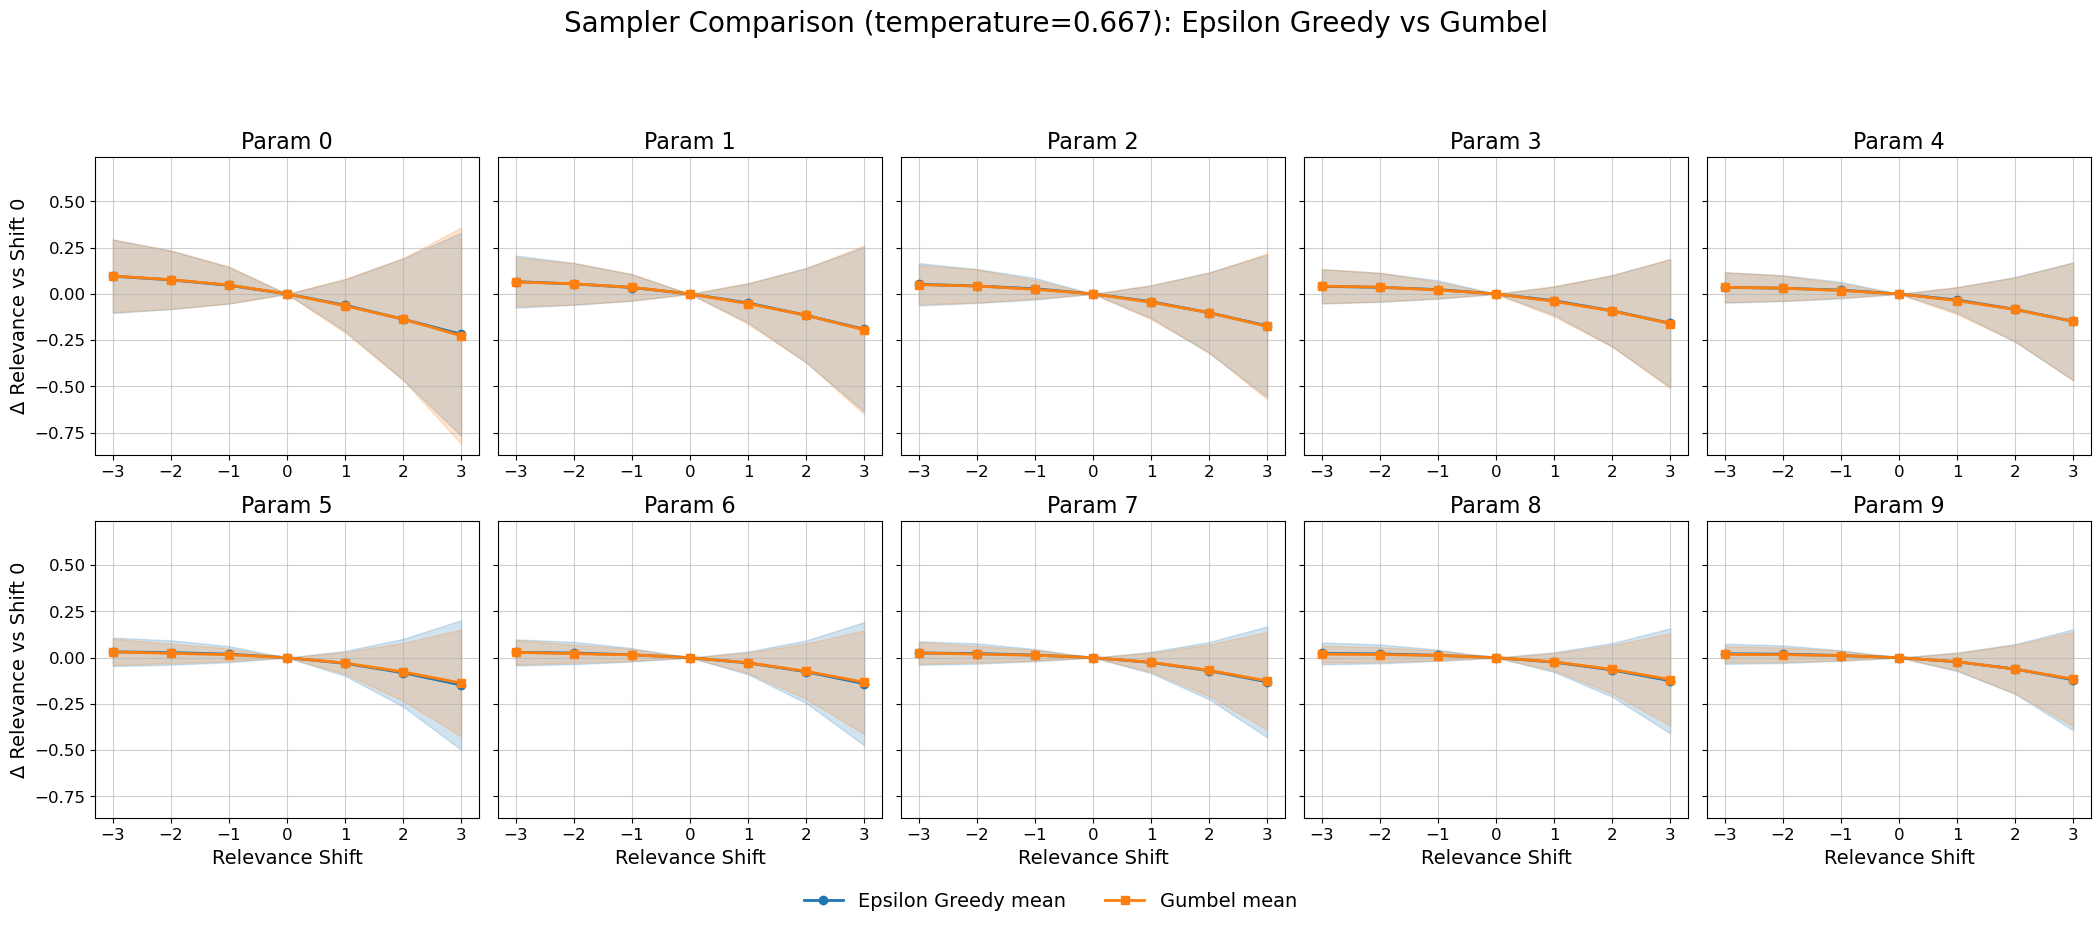

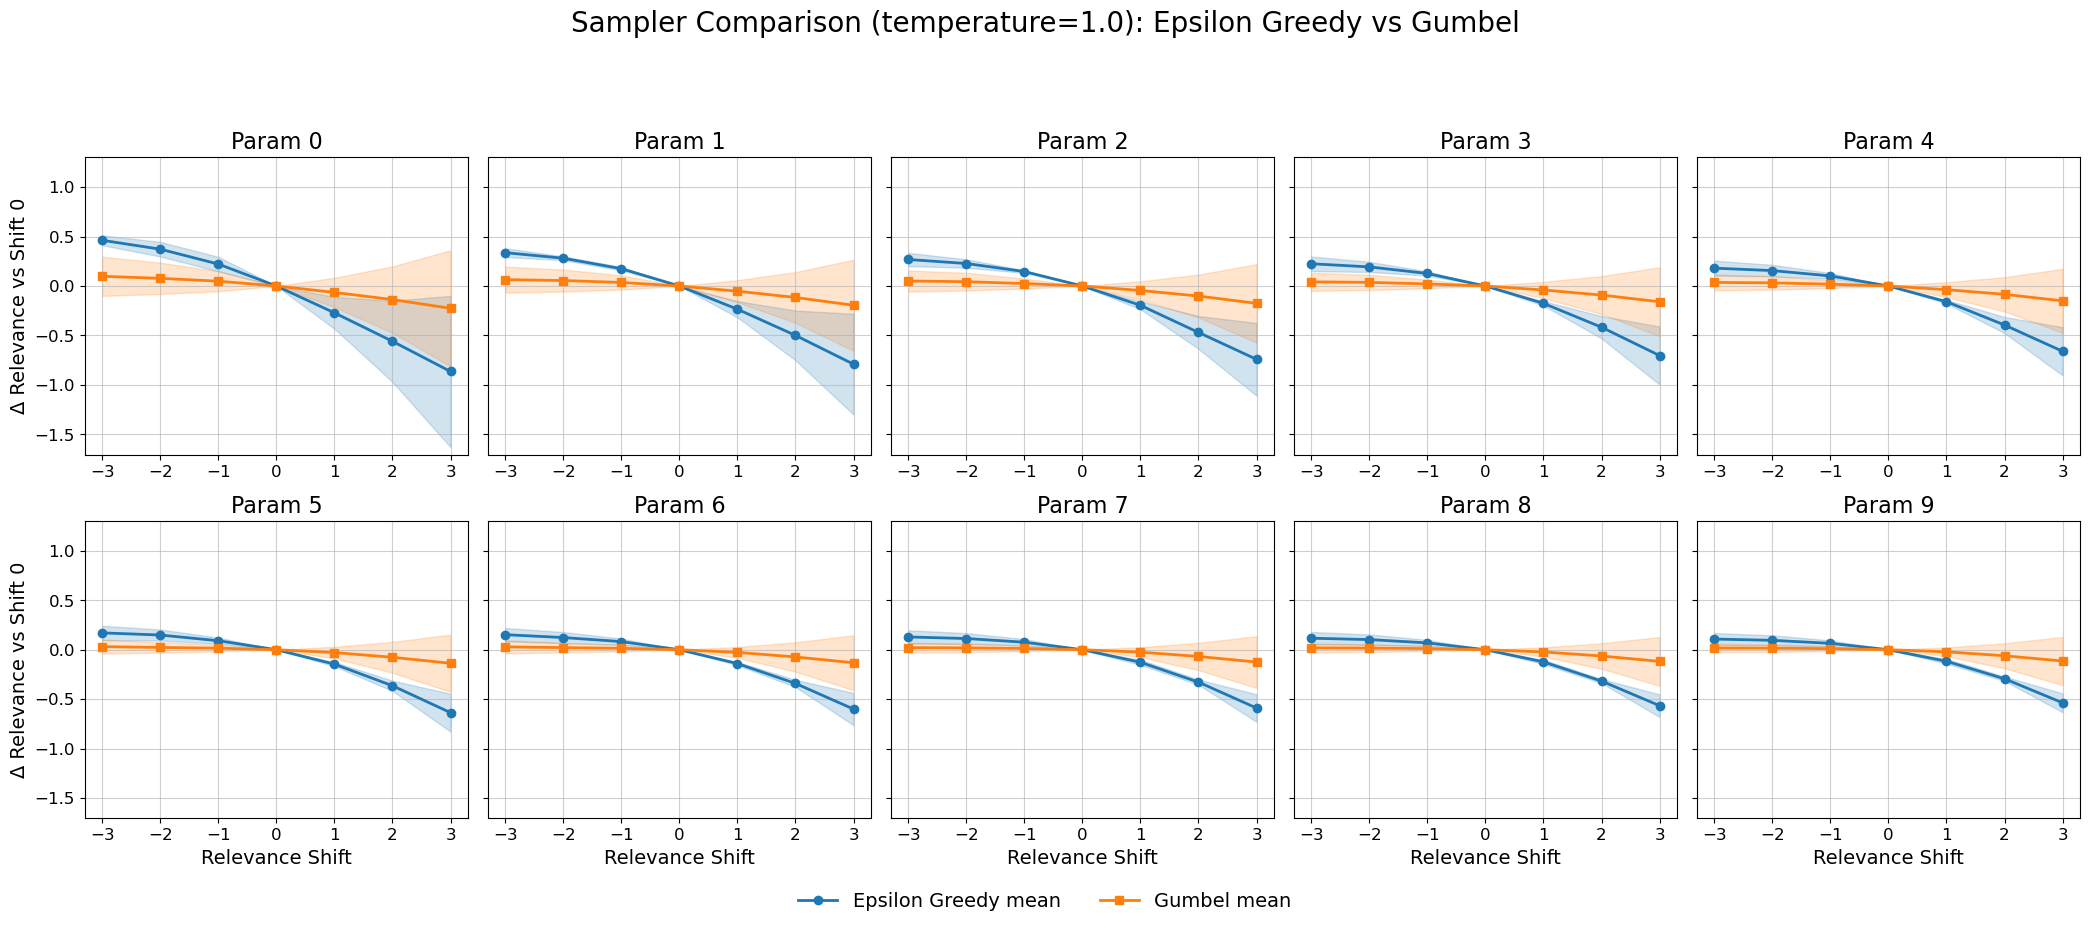

In [8]:

def plot_sampler_comparison(multi_relevance_df_a, multi_relevance_df_b, sampler_a, sampler_b, temperature):
    fig, axes = plt.subplots(2, 5, figsize=(21, 9), sharey=True)
    axes = axes.flatten()

    all_means = []
    all_stds = []

    for idx in range(10):
        ax = axes[idx]

        # --- Sampler A ---
        subset_a = multi_relevance_df_a[multi_relevance_df_a['param_idx'] == idx]
        baseline_a = subset_a[subset_a['relevance_shift'] == 0]['relevance'].reset_index(drop=True)
        diff_df_a = pd.DataFrame()
        for shift in sorted(subset_a['relevance_shift'].unique()):
            values = subset_a[subset_a['relevance_shift'] == shift]['relevance'].reset_index(drop=True)
            diff_df_a[shift] = values - baseline_a
        means_a, stds_a = diff_df_a.mean(), diff_df_a.std()

        # --- Sampler B ---
        subset_b = multi_relevance_df_b[multi_relevance_df_b['param_idx'] == idx]
        baseline_b = subset_b[subset_b['relevance_shift'] == 0]['relevance'].reset_index(drop=True)
        diff_df_b = pd.DataFrame()
        for shift in sorted(subset_b['relevance_shift'].unique()):
            values = subset_b[subset_b['relevance_shift'] == shift]['relevance'].reset_index(drop=True)
            diff_df_b[shift] = values - baseline_b
        means_b, stds_b = diff_df_b.mean(), diff_df_b.std()

        # Track ranges for global y-limits
        all_means.extend(means_a.values)
        all_means.extend(means_b.values)
        all_stds.extend(stds_a.values)
        all_stds.extend(stds_b.values)

        # --- Plot std bands first ---
        ax.fill_between(means_a.index, means_a - stds_a, means_a + stds_a, color='tab:blue', alpha=0.2)
        ax.fill_between(means_b.index, means_b - stds_b, means_b + stds_b, color='tab:orange', alpha=0.2)

        # --- Plot mean lines on top ---
        ax.plot(means_a.index, means_a.values, marker='o', color='tab:blue', label=f'{sampler_a} mean' if idx == 0 else "", linewidth=2)
        ax.plot(means_b.index, means_b.values, marker='s', color='tab:orange', label=f'{sampler_b} mean' if idx == 0 else "", linewidth=2)

        ax.set_title(f'Param {idx}', fontsize=16)
        ax.tick_params(axis='both', labelsize=12)
        ax.grid(True, alpha=0.6)

        if idx % 5 == 0:
            ax.set_ylabel('Δ Relevance vs Shift 0', fontsize=14)
        if idx >= 5:
            ax.set_xlabel('Relevance Shift', fontsize=14)

    # Adjust y-limits globally (10% margin)
    ymin = min(all_means) - max(all_stds) * 1.1
    ymax = max(all_means) + max(all_stds) * 1.1
    for ax in axes:
        ax.set_ylim(ymin, ymax)

    # Global title
    fig.suptitle(f'Sampler Comparison (temperature={temperature}): {sampler_a} vs {sampler_b}', fontsize=20, y=1.02)

    # Legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', fontsize=14, ncol=2, frameon=False)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


plot_sampler_comparison(
    multi_relevance_df_tmp_0333, multi_relevance_df_gumbel_0333,
    'Epsilon Greedy', 'Gumbel', 0.333
)

plot_sampler_comparison(
    multi_relevance_df_tmp_0667, multi_relevance_df_gumbel_0667,
    'Epsilon Greedy', 'Gumbel', 0.667
)

plot_sampler_comparison(
    multi_relevance_df_tmp_1, multi_relevance_df_gumbel_1,
    'Epsilon Greedy', 'Gumbel', 1.0
)


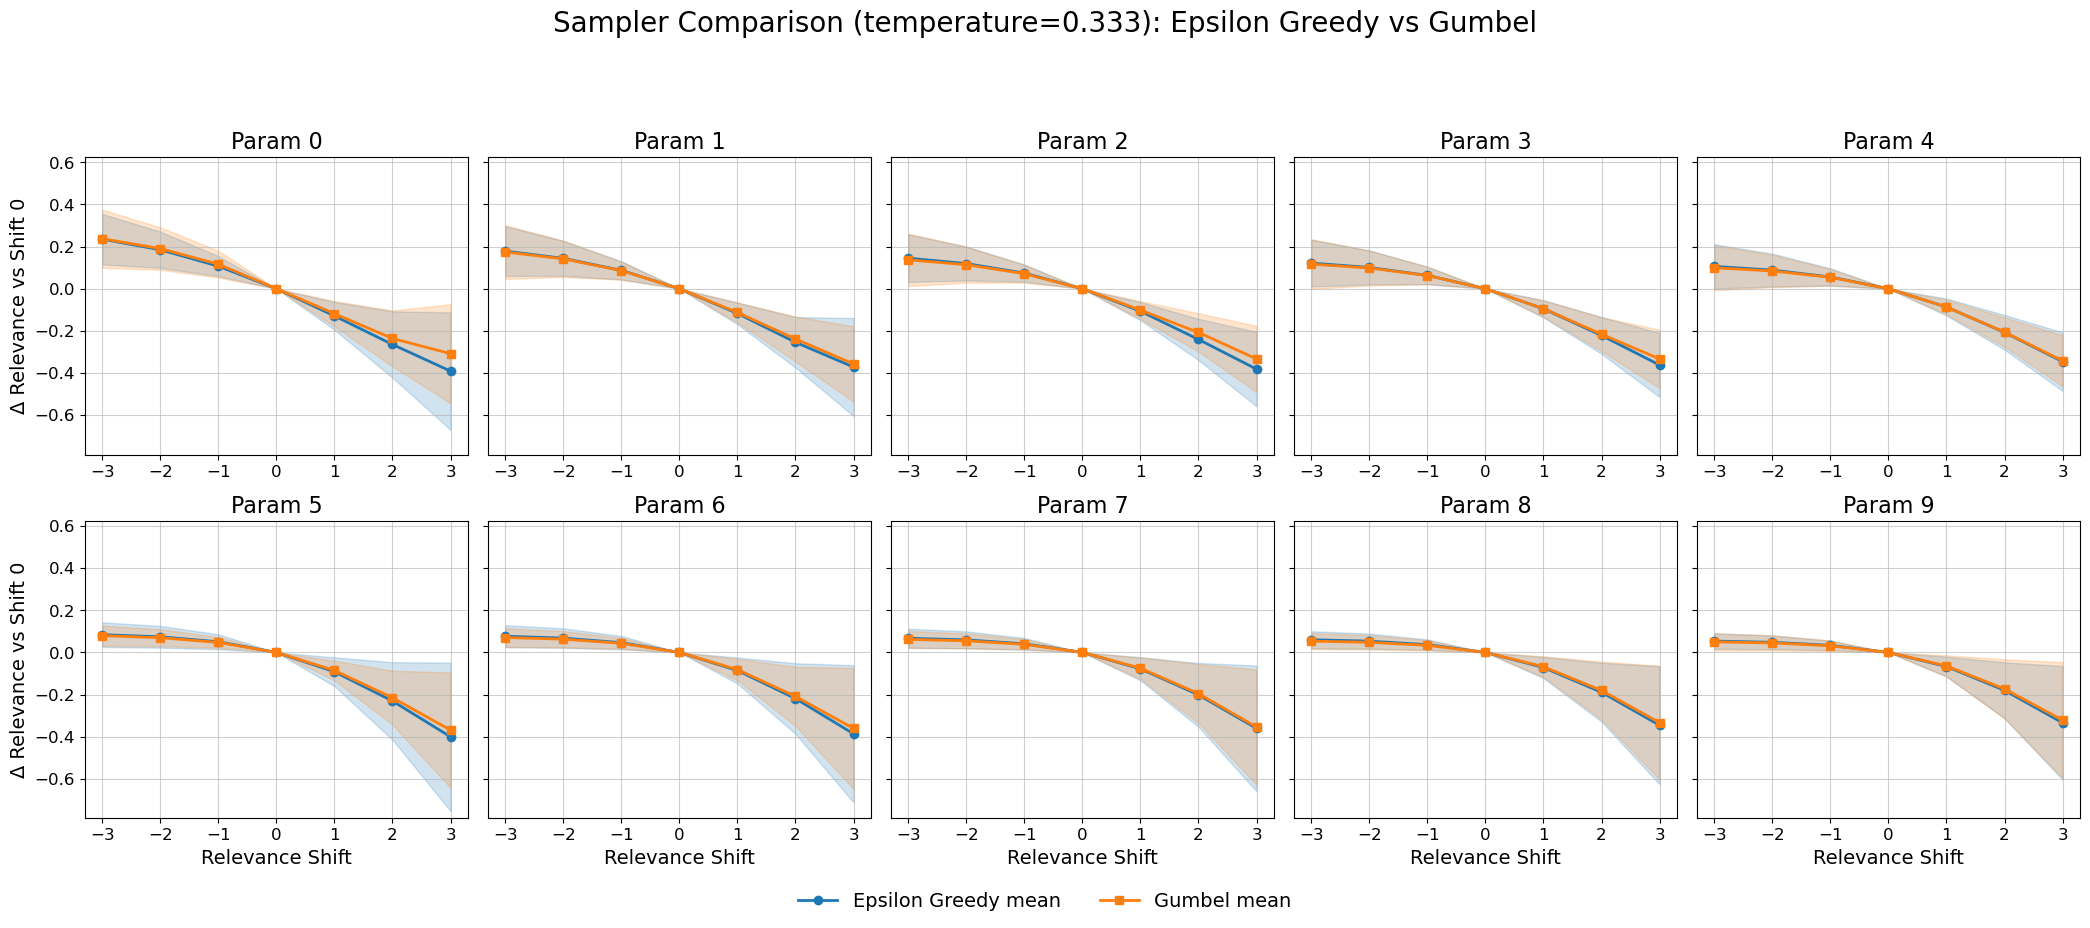

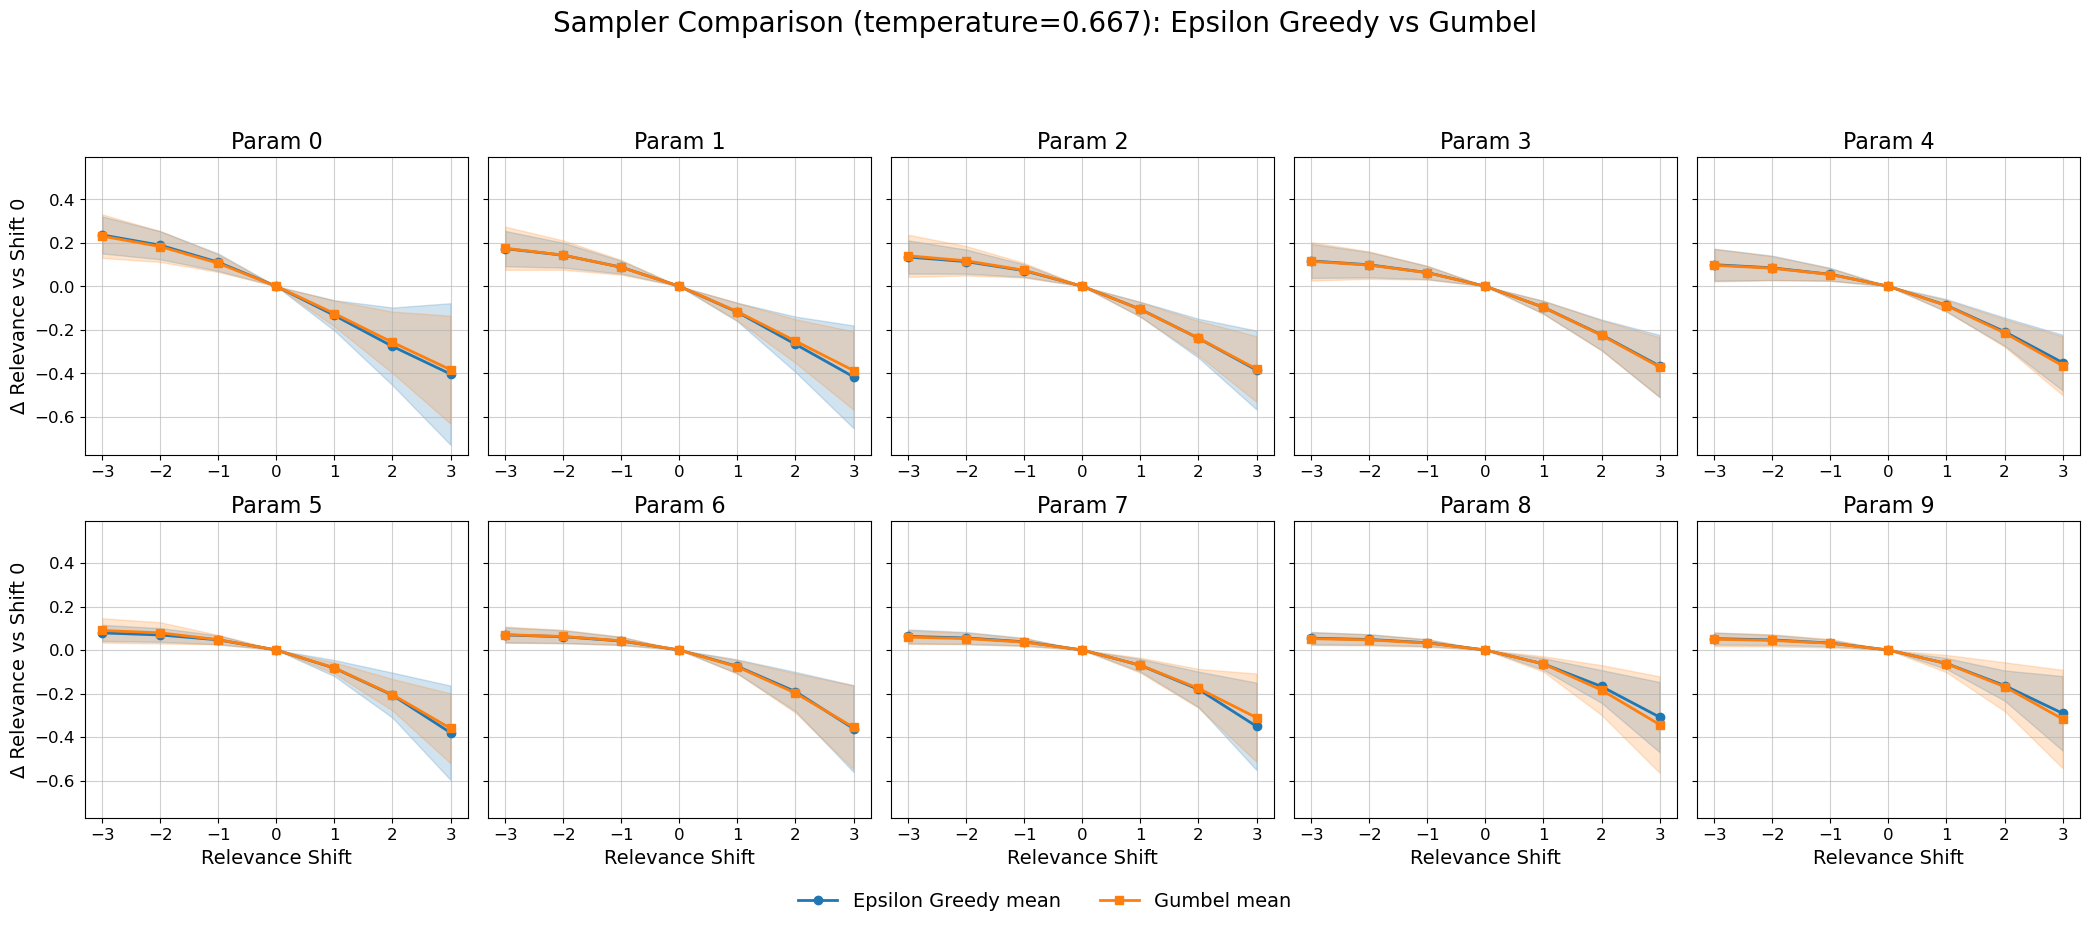

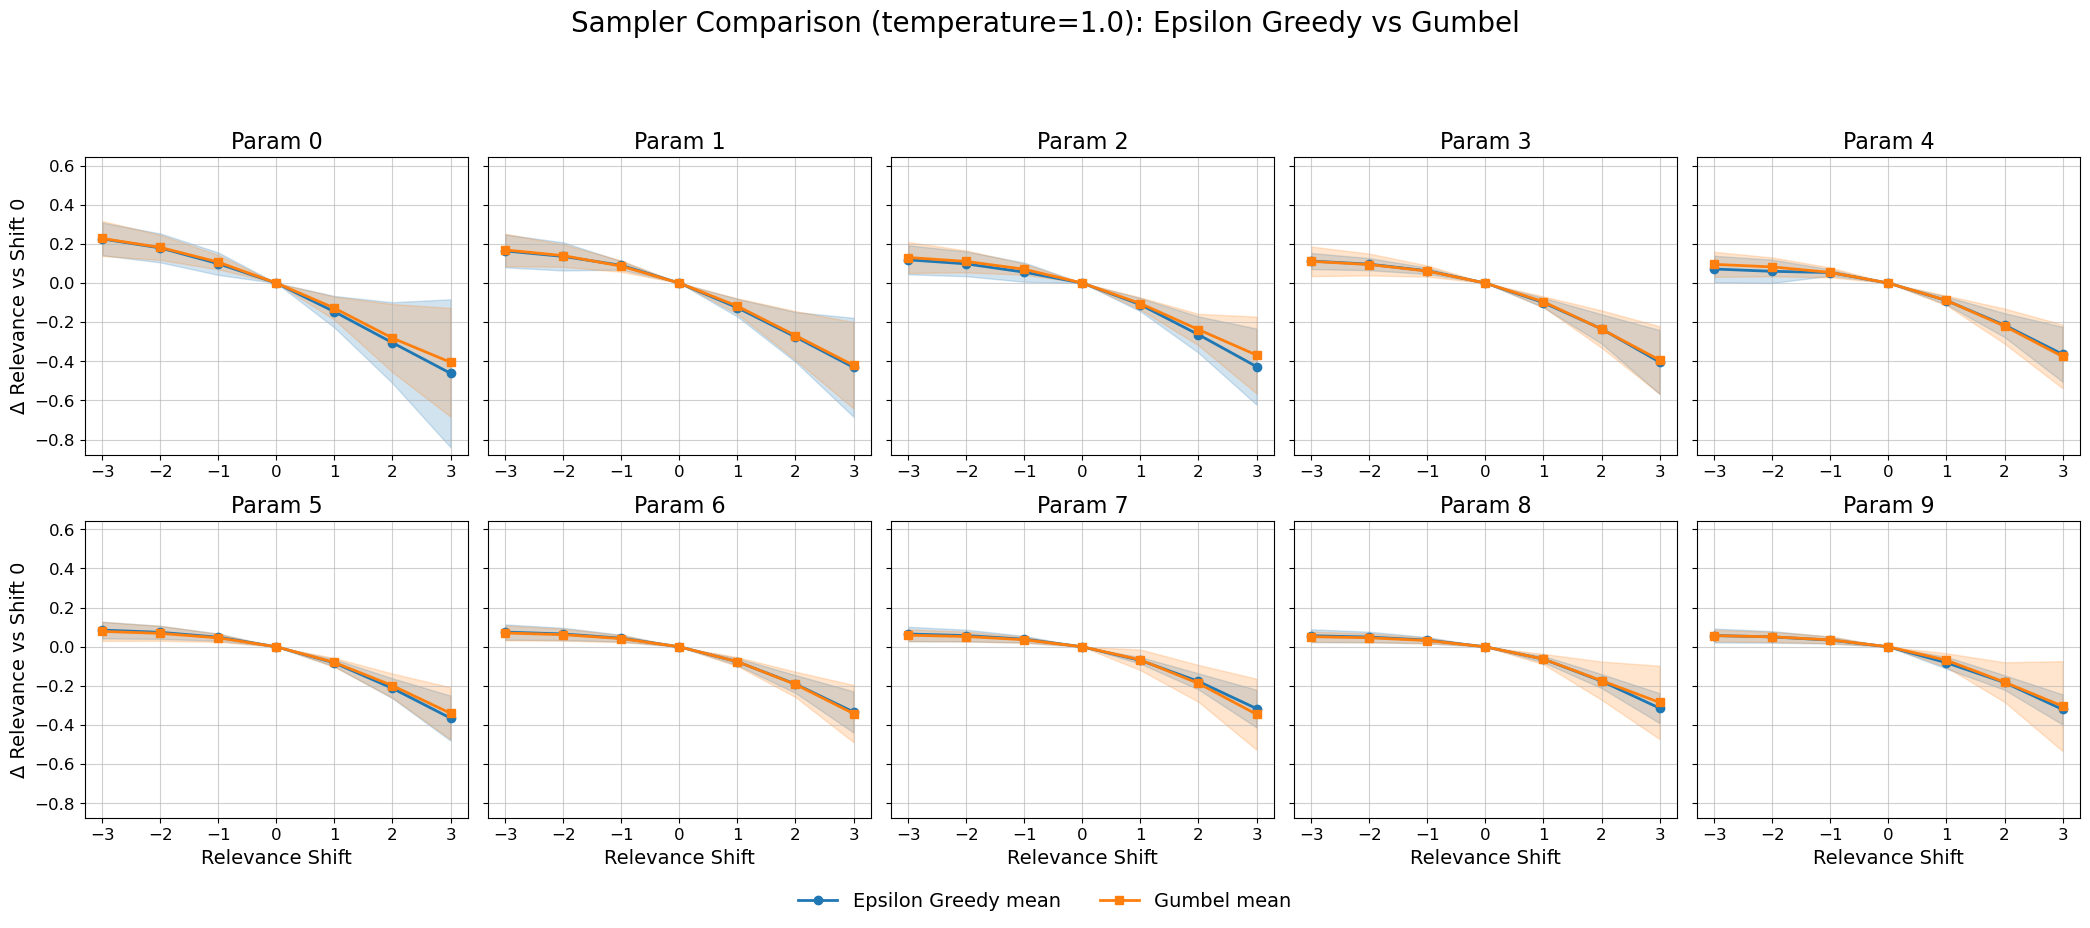

In [9]:
plot_sampler_comparison(
    multi_relevance_df_deep_0333, multi_relevance_df_gumbel_deep_0333,
    'Epsilon Greedy', 'Gumbel', 0.333
)

plot_sampler_comparison(
    multi_relevance_df_deep_0667, multi_relevance_df_gumbel_deep_0667,
    'Epsilon Greedy', 'Gumbel', 0.667
)   

plot_sampler_comparison(
    multi_relevance_df_deep_1, multi_relevance_df_gumbel_deep_1,
    'Epsilon Greedy', 'Gumbel', 1.0
)

In [10]:
import altair as alt
import pandas as pd

from notebooks.utils import load
from two_tower_confounding.simulation.simulator import get_position_bias

In [11]:
def theme():
    return {
        "config": {
             "title": {
                "font": "serif",
                "fontWeight": "normal",
                "fontSize": 16,
                "dx": 5,
                 "subtitleFont": "serif",
                 "subtitleFontSize": 14,
            },
            "axis": {
                "titleFont": "serif",
                "titleFontWeight": "normal",
                "titleFontSize": 16,
                "labelFont": "serif",
                "labelFontWeight": "normal",
                "labelFontSize": 14
            },
            "headerColumn": {
                "titleFont": "serif",
                "titleFontWeight": "normal",
                "titleFontSize": 16,
                "labelFont": "serif",
                "labelFontWeight": "normal",
                "labelFontSize": 16
            },
            "text": {
                "font": "serif",
                "fontSize": 14,
            },
            "legend": {
                "symbolOpacity": 1,
                "titleFont": "serif",
                "titleFontWeight": "normal",
                "titleFontSize": 16,
                "labelFont": "serif",
                "labelFontWeight": "normal",
                "labelFontSize": 16,
            }
        },
    }

alt.themes.register("latex", theme)
alt.themes.enable("latex")

/var/folders/nb/j_h4xjxd1tl7g7169hm8cdnc0000gn/T/ipykernel_85388/782434750.py:44: AltairDeprecationWarning: 
Deprecated since `altair=5.5.0`. Use altair.theme instead.
Most cases require only the following change:

    # Deprecated
    alt.themes.enable('quartz')

    # Updated
    alt.theme.enable('quartz')

If your code registers a theme, make the following change:

    # Deprecated
    def custom_theme():
        return {'height': 400, 'width': 700}
    alt.themes.register('theme_name', custom_theme)
    alt.themes.enable('theme_name')

    # Updated
    @alt.theme.register('theme_name', enable=True)
    def custom_theme():
        return alt.theme.ThemeConfig(
            {'height': 400, 'width': 700}
        )

See the updated User Guide for further details:
    https://altair-viz.github.io/user_guide/api.html#theme
    https://altair-viz.github.io/user_guide/customization.html#chart-themes
  alt.themes.register("latex", theme)


ThemeRegistry.enable('latex')

In [12]:
def plot_bias(experiment, policy_strength, sampler, title="", subtitle="", width=225, height=125, color="blues", show_axis_title=True):
    scheme = {
        "blue": ["#C6DBEF", "#9ECAE1", "#6BAED6", "#3182BD", "#636363"],
        "green": ["#C7E9C0", "#A1D99B", "#74C476", "#31A354", "#636363"],
        "orange": ["#FDD0A2", "#FD8D3C", "#FD8D3C", "#E6550E", "#636363"],
    }[color]

    
    bias_df = load(experiment, "bias.csv")
    bias_df = bias_df[bias_df["policy_strength"] == policy_strength]

    bias_df = bias_df[bias_df["logging_policy_sampler"] != sampler]

    n_positions = bias_df.position.max() + 1
    true_bias_df = pd.DataFrame(
        {
            "position": range(n_positions),
            "examination": get_position_bias(n_positions, 1),
            "policy_temperature": "Simulated Bias"
        }
    )

    bias_df = pd.concat([bias_df, true_bias_df])
    bias_df["position"] += 1

    base = alt.Chart(bias_df, width=width, height=height, title=alt.Title(text=title, subtitle=subtitle)).encode(
        x=alt.X("position:Q", title="Position").axis(labelAngle=0, values=[1, 5, 10, 15, 20, 25]).scale(nice=False)
    )
    
    line = base.mark_line(point=True, opacity=1).encode(
        y=alt.Y("mean(examination):Q", title="Bias Logits" if show_axis_title else None),
        color=alt.Color("policy_temperature:O", title="Temperature 𝜏").scale(range=scheme)
    )
    
    ci = base.mark_errorband(extent="ci").encode(
        y=alt.Y("examination:Q", title="Bias Logits" if show_axis_title else None),
        color=alt.Color("policy_temperature:O").scale(range=scheme)
    )
    
    return ci + line, bias_df





linear, linear_bias_df = plot_bias("test_single_varying", policy_strength=1, sampler="gumbel", color="green", title="Epsilion Greedy Sampler, Linear Relevance Tower", subtitle="linear rel., policy strength 𝛼 = 1")
deep, deep_bias_df = plot_bias("test_single_varying", policy_strength=1, sampler="nan", color="green", title="Gumbel Max Sampler, Linear Relevance Tower", subtitle="linear rel., policy strength 𝛼 = 1", show_axis_title=False)


chart = (
    linear | deep
).configure_line(
    size=2
).configure_point(
    size=15
).resolve_scale(
    y="shared"
).configure_concat(
    spacing=5
)



chart

alt.HConcatChart(...)

In [13]:
def plot_performance_grid_all_temps(multi_performance_dfs, temperatures, metric='ndcg@10'):
    """
    Plot metric vs Relevance Shift for each param_idx in a grid,
    overlaying results for multiple temperatures.

    Args:
        multi_performance_dfs (list[pd.DataFrame]): list of DataFrames, one per temperature
        temperatures (list): list of temperature values (same order as dfs)
        metric (str): performance metric to plot (default 'ndcg@10')
    """
    # Determine unique param indices from the first df
    all_param_indices = sorted(multi_performance_dfs[0]['param_idx'].unique())
    n_params = len(all_param_indices)

    # Compute grid size (2 rows if >5 params, else 1 row)
    n_cols = min(5, n_params)
    n_rows = int(np.ceil(n_params / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 4 * n_rows), sharey=True)
    axes = np.array(axes).flatten()  # Flatten in case of 2D axes

    for i, idx in enumerate(all_param_indices):
        ax = axes[i]
        for df, temp in zip(multi_performance_dfs, temperatures):
            subset = df[df['param_idx'] == idx]
            if subset.empty:
                continue
            ax.plot(subset['relevance_shift'], subset[metric], marker='o', linewidth=2, label=f'T={temp}')

        ax.set_title(f'Param {idx}', fontsize=14)
        ax.tick_params(axis='both', labelsize=12)
        ax.grid(True, alpha=0.6)

        if i % n_cols == 0:
            ax.set_ylabel(metric, fontsize=12)
        if i >= (n_rows - 1) * n_cols:
            ax.set_xlabel('Relevance Shift', fontsize=12)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Global title
    fig.suptitle(f'{metric.upper()} vs Relevance Parameter Shift Across Temperatures',
                 fontsize=18, y=1.02)

    # Shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='lower center', fontsize=12,
                   ncol=len(temperatures), frameon=False)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()



prefix_performance_clicks = 'test_clicks_param_shift_'
prefix_performance_relevance = 'test_relevance_param_shift_'


multi_performance_df_tmp_0 = load_and_concat_multi_shift_files(folder_path_tmp_0, prefix_performance_relevance, 'relevance_shift', 'param_idx')
multi_performance_df_tmp_0333 = load_and_concat_multi_shift_files(folder_path_tmp_0333, prefix_performance_relevance, 'relevance_shift', 'param_idx')
multi_performance_df_tmp_0667 = load_and_concat_multi_shift_files(folder_path_tmp_0667, prefix_performance_relevance, 'relevance_shift', 'param_idx')
multi_performance_df_tmp_1 = load_and_concat_multi_shift_files(folder_path_tmp_1, prefix_performance_relevance, 'relevance_shift', 'param_idx')

plot_performance_grid_all_temps(
    [multi_performance_df_tmp_0,
     multi_performance_df_tmp_0333,
     multi_performance_df_tmp_0667,
     multi_performance_df_tmp_1],
    [0, 0.333, 0.667, 1],
    metric='ndcg'
)

multi_performance_df_tmp_0 = load_and_concat_multi_shift_files(folder_path_tmp_0, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_tmp_0333 = load_and_concat_multi_shift_files(folder_path_tmp_0333, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_tmp_0667 = load_and_concat_multi_shift_files(folder_path_tmp_0667, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_tmp_1 = load_and_concat_multi_shift_files(folder_path_tmp_1, prefix_performance_clicks , 'relevance_shift', 'param_idx')

plot_performance_grid_all_temps(
    [multi_performance_df_tmp_0,
     multi_performance_df_tmp_0333,
     multi_performance_df_tmp_0667, 
     multi_performance_df_tmp_1],
    [0, 0.333, 0.667, 1],
    metric='loss'
)

['test_relevance_param_shift_1.0_idx1.csv', 'test_relevance_param_shift_-3.0_idx1.csv', 'test_relevance_param_shift_-3.0_idx0.csv', 'test_relevance_param_shift_1.0_idx0.csv', 'test_relevance_param_shift_1.0_idx2.csv', 'test_relevance_param_shift_-3.0_idx2.csv', 'test_relevance_param_shift_-3.0_idx3.csv', 'test_relevance_param_shift_1.0_idx3.csv', 'test_relevance_param_shift_-3.0_idx7.csv', 'test_relevance_param_shift_1.0_idx7.csv', 'test_relevance_param_shift_2.0_idx9.csv', 'test_relevance_param_shift_2.0_idx8.csv', 'test_relevance_param_shift_1.0_idx6.csv', 'test_relevance_param_shift_-3.0_idx6.csv', 'test_relevance_param_shift_-3.0_idx4.csv', 'test_relevance_param_shift_1.0_idx4.csv', 'test_relevance_param_shift_1.0_idx5.csv', 'test_relevance_param_shift_-3.0_idx5.csv', 'test_relevance_param_shift_3.0_idx0.csv', 'test_relevance_param_shift_-1.0_idx0.csv', 'test_relevance_param_shift_-1.0_idx1.csv', 'test_relevance_param_shift_3.0_idx1.csv', 'test_relevance_param_shift_3.0_idx3.csv', 

NameError: name 'np' is not defined

['test_relevance_param_shift_1.0_idx1.csv', 'test_relevance_param_shift_-3.0_idx1.csv', 'test_relevance_param_shift_-3.0_idx0.csv', 'test_relevance_param_shift_1.0_idx0.csv', 'test_relevance_param_shift_1.0_idx2.csv', 'test_relevance_param_shift_-3.0_idx2.csv', 'test_relevance_param_shift_3.0_idx0.csv', 'test_relevance_param_shift_-1.0_idx0.csv', 'test_relevance_param_shift_-1.0_idx1.csv', 'test_relevance_param_shift_3.0_idx1.csv', 'test_relevance_param_shift_-1.0_idx2.csv', 'test_relevance_param_shift_3.0_idx2.csv', 'test_relevance_param_shift_0.0_idx1.csv', 'test_relevance_param_shift_-2.0_idx1.csv', 'test_relevance_param_shift_-2.0_idx0.csv', 'test_relevance_param_shift_0.0_idx0.csv', 'test_relevance_param_shift_0.0_idx2.csv', 'test_relevance_param_shift_-2.0_idx2.csv', 'test_relevance_param_shift_2.0_idx0.csv', 'test_relevance_param_shift_2.0_idx1.csv', 'test_relevance_param_shift_2.0_idx2.csv']
['test_relevance_param_shift_1.0_idx1.csv', 'test_relevance_param_shift_-3.0_idx1.csv',

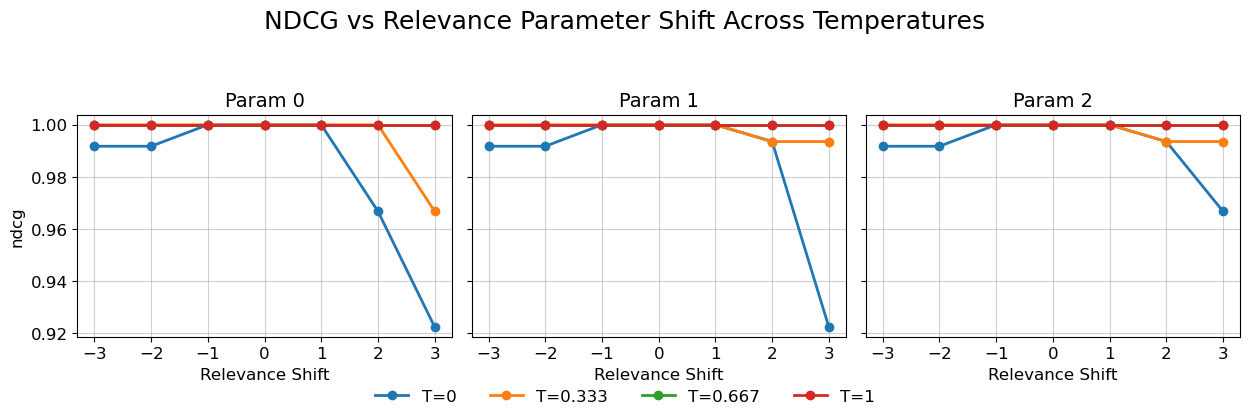

['test_clicks_param_shift_0.0_idx2.csv', 'test_clicks_param_shift_0.0_idx1.csv', 'test_clicks_param_shift_0.0_idx0.csv', 'test_clicks_param_shift_-1.0_idx0.csv', 'test_clicks_param_shift_-1.0_idx1.csv', 'test_clicks_param_shift_-1.0_idx2.csv', 'test_clicks_param_shift_2.0_idx2.csv', 'test_clicks_param_shift_2.0_idx0.csv', 'test_clicks_param_shift_2.0_idx1.csv', 'test_clicks_param_shift_-3.0_idx1.csv', 'test_clicks_param_shift_-3.0_idx0.csv', 'test_clicks_param_shift_-3.0_idx2.csv', 'test_clicks_param_shift_1.0_idx2.csv', 'test_clicks_param_shift_1.0_idx1.csv', 'test_clicks_param_shift_1.0_idx0.csv', 'test_clicks_param_shift_-2.0_idx1.csv', 'test_clicks_param_shift_-2.0_idx0.csv', 'test_clicks_param_shift_-2.0_idx2.csv', 'test_clicks_param_shift_3.0_idx2.csv', 'test_clicks_param_shift_3.0_idx0.csv', 'test_clicks_param_shift_3.0_idx1.csv']
['test_clicks_param_shift_0.0_idx2.csv', 'test_clicks_param_shift_0.0_idx1.csv', 'test_clicks_param_shift_0.0_idx0.csv', 'test_clicks_param_shift_-1.0

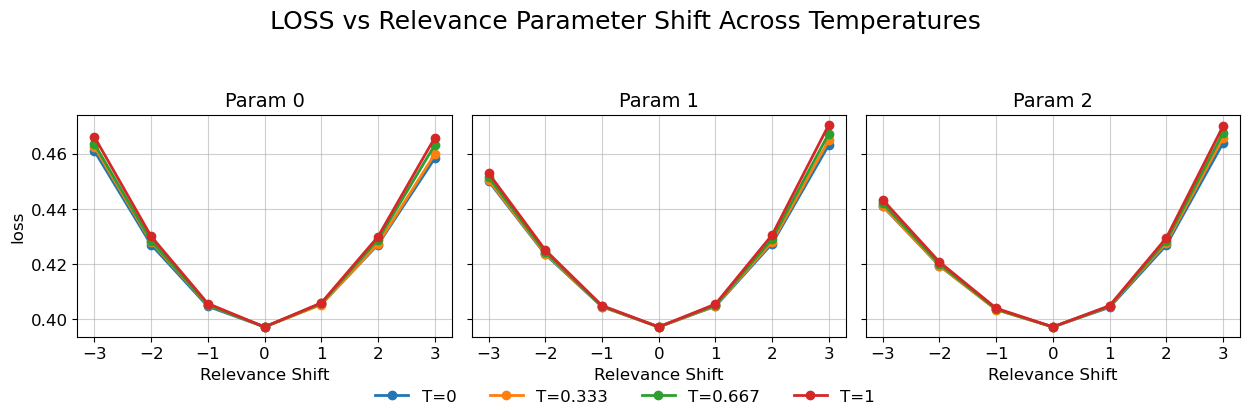

['test_clicks_param_shift_0.0_idx2.csv', 'test_clicks_param_shift_-2.0_idx8.csv', 'test_clicks_param_shift_-1.0_idx6.csv', 'test_clicks_param_shift_-1.0_idx7.csv', 'test_clicks_param_shift_-2.0_idx9.csv', 'test_clicks_param_shift_0.0_idx3.csv', 'test_clicks_param_shift_0.0_idx1.csv', 'test_clicks_param_shift_-1.0_idx5.csv', 'test_clicks_param_shift_-1.0_idx4.csv', 'test_clicks_param_shift_0.0_idx0.csv', 'test_clicks_param_shift_0.0_idx4.csv', 'test_clicks_param_shift_-1.0_idx0.csv', 'test_clicks_param_shift_-1.0_idx1.csv', 'test_clicks_param_shift_0.0_idx5.csv', 'test_clicks_param_shift_0.0_idx7.csv', 'test_clicks_param_shift_3.0_idx9.csv', 'test_clicks_param_shift_-1.0_idx3.csv', 'test_clicks_param_shift_-1.0_idx2.csv', 'test_clicks_param_shift_3.0_idx8.csv', 'test_clicks_param_shift_0.0_idx6.csv', 'test_clicks_param_shift_-3.0_idx7.csv', 'test_clicks_param_shift_2.0_idx3.csv', 'test_clicks_param_shift_2.0_idx2.csv', 'test_clicks_param_shift_-3.0_idx6.csv', 'test_clicks_param_shift_-3

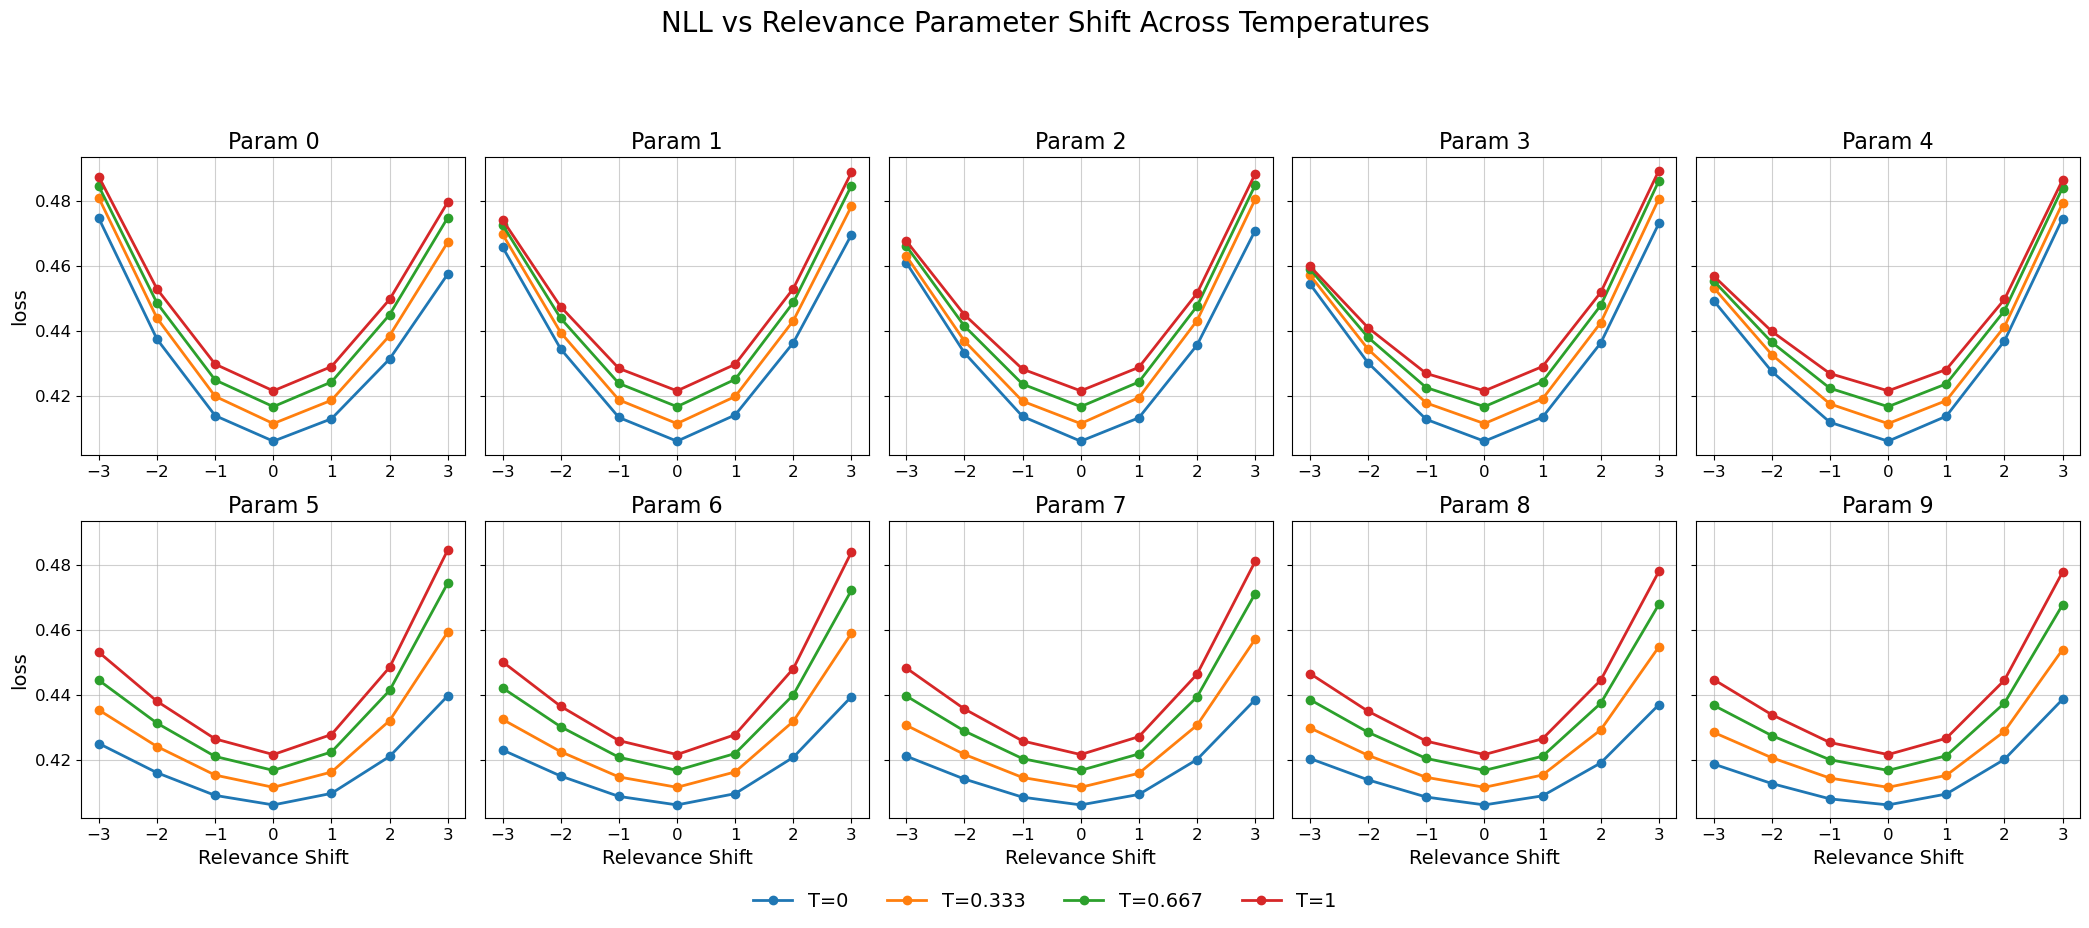

['test_relevance_param_shift_1.0_idx1.csv', 'test_relevance_param_shift_-3.0_idx1.csv', 'test_relevance_param_shift_-3.0_idx0.csv', 'test_relevance_param_shift_1.0_idx0.csv', 'test_relevance_param_shift_1.0_idx2.csv', 'test_relevance_param_shift_-3.0_idx2.csv', 'test_relevance_param_shift_-3.0_idx3.csv', 'test_relevance_param_shift_1.0_idx3.csv', 'test_relevance_param_shift_-3.0_idx7.csv', 'test_relevance_param_shift_1.0_idx7.csv', 'test_relevance_param_shift_2.0_idx9.csv', 'test_relevance_param_shift_2.0_idx8.csv', 'test_relevance_param_shift_1.0_idx6.csv', 'test_relevance_param_shift_-3.0_idx6.csv', 'test_relevance_param_shift_-3.0_idx4.csv', 'test_relevance_param_shift_1.0_idx4.csv', 'test_relevance_param_shift_1.0_idx5.csv', 'test_relevance_param_shift_-3.0_idx5.csv', 'test_relevance_param_shift_3.0_idx0.csv', 'test_relevance_param_shift_-1.0_idx0.csv', 'test_relevance_param_shift_-1.0_idx1.csv', 'test_relevance_param_shift_3.0_idx1.csv', 'test_relevance_param_shift_3.0_idx3.csv', 

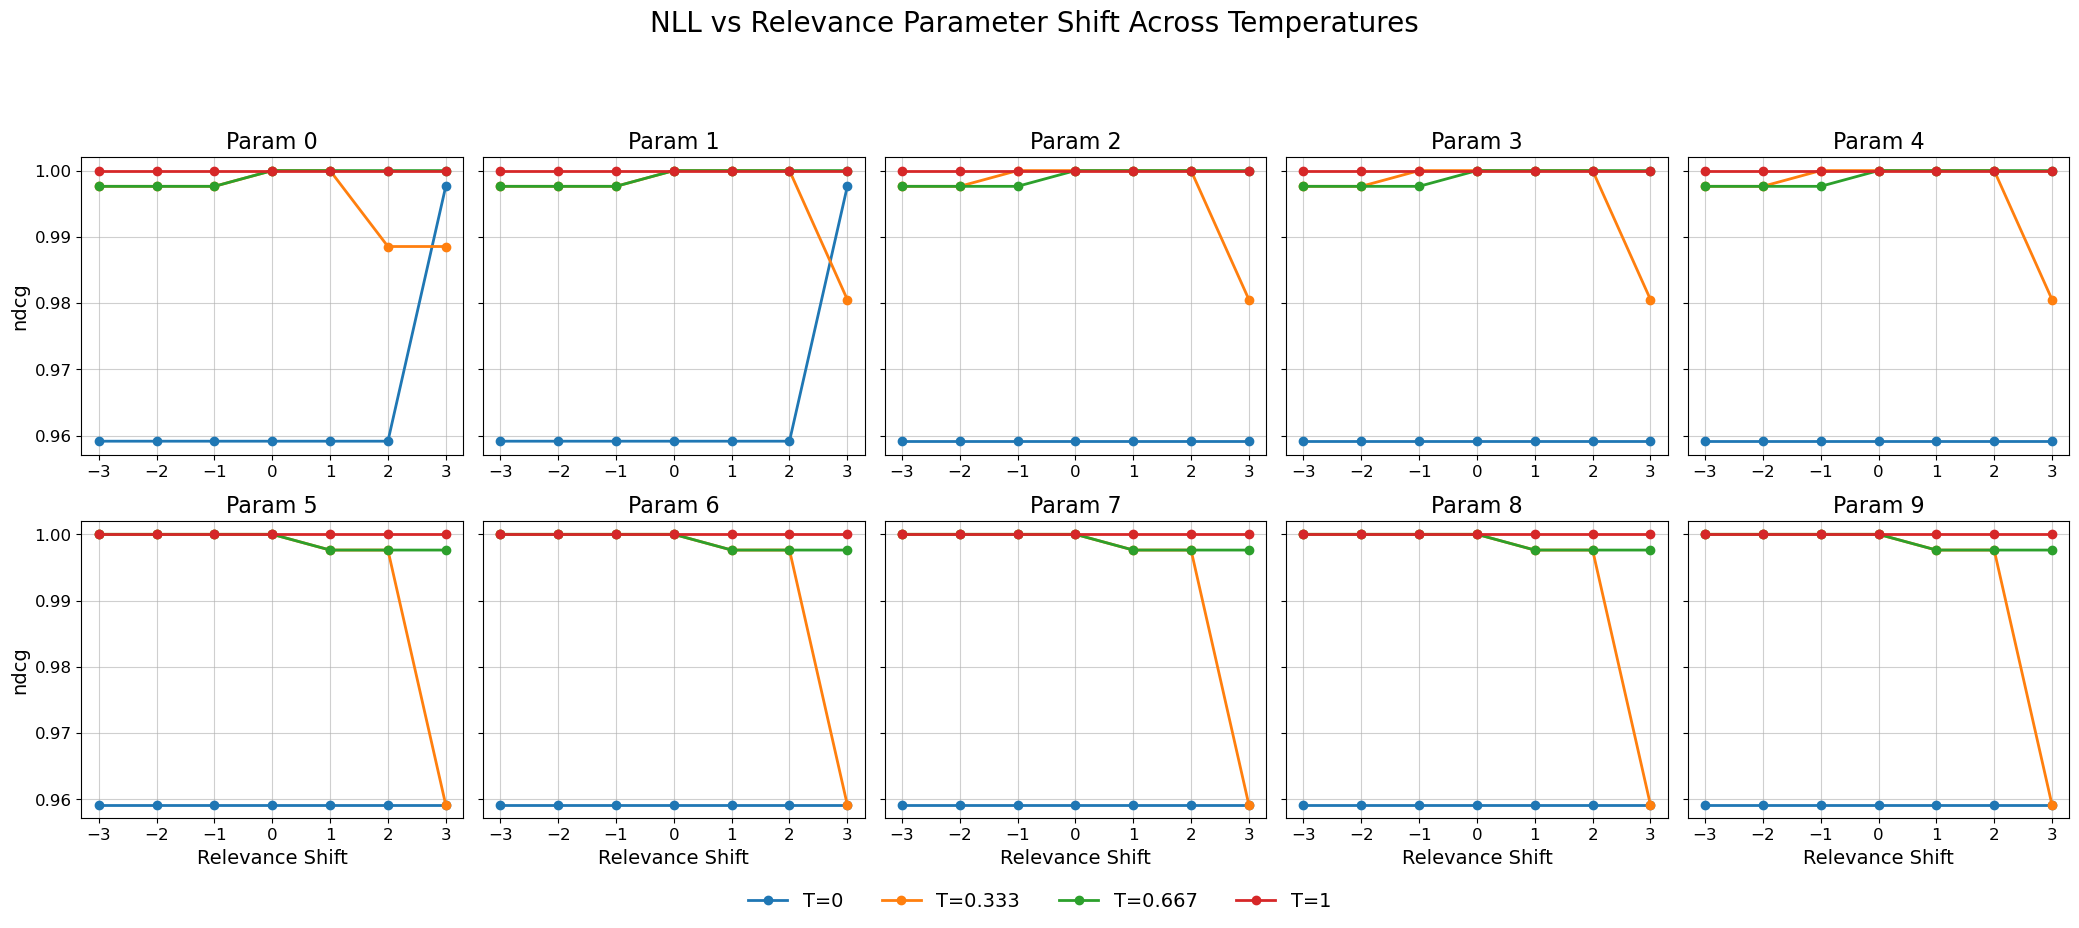

In [234]:

multi_performance_df_tmp_0 = load_and_concat_multi_shift_files(folder_path_deep_0, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_tmp_0333 = load_and_concat_multi_shift_files(folder_path_deep_0333, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_tmp_0667 = load_and_concat_multi_shift_files(folder_path_deep_0667, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_tmp_1 = load_and_concat_multi_shift_files(folder_path_deep_1, prefix_performance_clicks, 'relevance_shift', 'param_idx')


plot_performance_grid_all_temps(
    [multi_performance_df_tmp_0,
     multi_performance_df_tmp_0333,
     multi_performance_df_tmp_0667,
     multi_performance_df_tmp_1],
    [0, 0.333, 0.667, 1],
    metric='loss'
)

multi_performance_df_tmp_0 = load_and_concat_multi_shift_files(folder_path_deep_0, prefix_performance_relevance, 'relevance_shift', 'param_idx')
multi_performance_df_tmp_0333 = load_and_concat_multi_shift_files(folder_path_deep_0333, prefix_performance_relevance, 'relevance_shift', 'param_idx')
multi_performance_df_tmp_0667 = load_and_concat_multi_shift_files(folder_path_deep_0667, prefix_performance_relevance, 'relevance_shift', 'param_idx')
multi_performance_df_tmp_1 = load_and_concat_multi_shift_files(folder_path_deep_1, prefix_performance_relevance, 'relevance_shift', 'param_idx')

plot_performance_grid_all_temps(
    [multi_performance_df_tmp_0,
     multi_performance_df_tmp_0333,
     multi_performance_df_tmp_0667,
     multi_performance_df_tmp_1],
    [0, 0.333, 0.667, 1],
    metric='ndcg'
)